# Modeling Citation Trustworthiness in Evolving Scholarly Networks

This notebook implements the experimental pipeline of the project **Modeling Citation Trustworthiness in Evolving Scholarly Networks**.

The goal of the project is to assess the trustworthiness of citation links in a large evolving scholarly citation network. The citation data is represented as a graph, where each paper is a node and each citation is an edge. Since citation networks change over time, the system builds yearly graph snapshots and analyzes how citation links behave across different years.

The main idea is to compare original citation edges with injected noise edges. Original citation edges are expected to have stronger structural support in the graph, while injected noise edges are expected to be less stable. The system evaluates this behavior using graph embedding models, link reconstruction, and stability scores.

# Pipeline Overview

The implementation consists of the following steps:

1. **Input Dataset:** Loading the OpenAlex citation dataset used for the citation network analysis.

2. **Data Preparation:** Cleaning and organizing the citation data, including paper identifiers, citation links, and publication years.

3. **Snapshot Construction:** Building yearly citation network snapshots to analyze how the citation graph evolves over time.

4. **Feature Extraction:** Extracting structural and citation-based features that describe each paper in the network.

5. **Noise Injection:** Adding injected noise edges to create a controlled comparison between original and artificial citation links.

6. **Graph Perturbation:** Temporarily removing sampled citation edges to test whether the models can reconstruct them.

7. **Graph Embedding:** Applying Node2Vec and GraphSAGE to generate vector representations of papers in the citation network.

8. **Link Reconstruction:** Predicting whether removed citation links can be reconstructed using the learned embeddings.

9. **Stability Evaluation:** Computing stability scores and comparing original edges with injected noise edges.

10. **Results and Analysis:** Saving the results, generating plots, and analyzing citation trustworthiness over time.


# Tools and Frameworks

This project uses several Python libraries and frameworks:

- **Google Colab**  
  Used as the main cloud-based development and execution environment.

- **Google Drive**  
  Used for storing datasets, checkpoints, intermediate files, and final results.

- **Python**  
  Used as the main programming language for data processing, graph construction, model execution, and evaluation.

- **Pandas and NumPy**  
  Used for loading, filtering, processing, and analyzing citation data.

- **NetworkX**  
  Used for graph construction and calculation of graph-based features such as degree, PageRank, clustering coefficient, and centrality measures.

- **Node2Vec**  
  Used to generate graph embeddings based on biased random walks.

- **PyTorch and PyTorch Geometric**  
  Used to implement and train the GraphSAGE model.

- **Scikit-learn**  
  Used for evaluation metrics such as AUC-ROC and for supporting analysis tasks.

- **Matplotlib**  
  Used to generate visualizations, plots, and result graphs.

- **Pickle / CSV Files**  
  Used for saving checkpoints, iteration histories, edge scores, and yearly summary results.

## Install Required Libraries

Installs the main Python packages needed to run the project in Google Colab, including PyTorch Geometric and Node2Vec.


In [ ]:
# Install PyTorch and PyTorch Geometric for GraphSAGE implementation.
!pip install torch torch_geometric

# Install Node2Vec library for random-walk-based graph embeddings.
!pip install node2vec

## Project Setup and Global Parameters

Imports the required libraries and defines the main project settings, such as years, paths, embedding size, number of iterations, and noise rate.


In [ ]:
# ==============================================================================
# Modeling Citation Trustworthiness - Static Network Analysis
# Method I: Node2Vec
# Method II: GraphSAGE
# Adapted for Google Colab
# ==============================================================================

import os
import gc
import psutil
import shutil
import random
import warnings
import pickle
import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import sqlite3

from tqdm import tqdm
from numpy.linalg import norm
from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import StandardScaler

from google.colab import drive

warnings.filterwarnings("ignore")

# Node2Vec
from node2vec import Node2Vec

# GraphSAGE / PyTorch
import torch
import torch.nn.functional as F
from torch_geometric.data import Data
from torch_geometric.nn import SAGEConv


# ==============================================================================
# Global Parameters
# ==============================================================================

# ---------- General ----------
DRIVE_PATH = "/content/drive/MyDrive/openalex_cs_dataset/"
NODES_FILE = "nodes.csv"
EDGES_FILE = "edges.csv"
START_YEAR = 2015
END_YEAR = 2024
SNAPSHOT_MODE = "cumulative"
SKIP_COMPLETED_YEARS = True
NOISE_FRACTION = 0.05
# Fraction of edges temporarily removed for link reconstruction testing
FR_FRACTION = 0.20
# Minimum stability score required to classify an edge as stable/trustworthy
THRESHOLD = 0.60
# Fixed seed used to make the random process reproducible
RANDOM_SEED = 42

# ---------- Node2Vec Parameters ----------
# Size of the embedding vector created for each node
N2V_DIMENSIONS = 64
# Number of nodes visited in each random walk
N2V_WALK_LENGTH = 10
# Number of random walks started from each node
N2V_NUM_WALKS = 20
N2V_P = 0.5
N2V_Q = 1.0

# ---------- GraphSAGE Parameters ----------
# Size of the hidden representation learned inside the GraphSAGE model
SAGE_HIDDEN_DIM = 128
# Each node gets a final embedding vector of size 128
SAGE_OUTPUT_DIM = 128
SAGE_EPOCHS = 160
# Learning rate that controls how fast the model updates its weights
SAGE_LR = 0.005
# Number of edge samples processed together in one training batch
BATCH_SIZE = 10
TARGET_ITERATIONS_PER_YEAR = 20

#Use only 20% of original edges per iteration.
TRUE_EDGE_SAMPLE_FRACTION = 0.20
#False for Node2Vec to save RAM, True for GraphSAGE because it uses node features.
CALCULATE_ADVANCED_METRICS = False

random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)

print("All libraries imported successfully.")
print("Global parameters are ready.")

All libraries imported successfully.
Global parameters are ready.


### Project Paths Configuration

This cell defines the main project folders used for snapshots, GraphSAGE results, Node2Vec results, database files, and visualizations.  
All paths are centralized here to avoid duplication and make the notebook easier to maintain.  
The required folders are created automatically if they do not already exist.

In [ ]:
# ------------------------------------------------------------------------------
# Main folders
# ------------------------------------------------------------------------------

# Base folder in Google Drive for saving all yearly experiment files.
YEARLY_BASE_DIR = "/content/gdrive/MyDrive/Final_project"

# Folder that contains yearly snapshot files.
SNAPSHOTS_DIR = os.path.join(YEARLY_BASE_DIR, "snapshots")

# Folder for GraphSAGE checkpoints and results.
GRAPHSAGE_CHECKPOINT_DIR = os.path.join(YEARLY_BASE_DIR, "graphsage_checkpoints")
RESULTS_DIR = os.path.join(YEARLY_BASE_DIR, "graphsage_results")
GRAPHSAGE_RESULTS_DIR = os.path.join(YEARLY_BASE_DIR, "graphsage_results")
CHECKPOINT_DIR = GRAPHSAGE_CHECKPOINT_DIR


# Folder for saving Node2Vec results.
NODE2VEC_RESULTS_DIR = os.path.join(YEARLY_BASE_DIR, "node2vec_results")

# Folder for saving visualization outputs.
VISUALIZATION_DIR = os.path.join(YEARLY_BASE_DIR, "visualization_results")

# ------------------------------------------------------------------------------
# Visualization subfolders
# ------------------------------------------------------------------------------

# Folder for GraphSAGE yearly histograms.
GRAPHSAGE_HIST_DIR = os.path.join(VISUALIZATION_DIR, "GraphSAGE_histograms_per_year")

# Folder for Node2Vec yearly histograms.
NODE2VEC_HIST_DIR = os.path.join(VISUALIZATION_DIR, "Node2Vec_histograms_per_year")

# ------------------------------------------------------------------------------
# Node2Vec SQLite database paths
# ------------------------------------------------------------------------------

# Local SQLite database file for faster writing during runtime.
NODE2VEC_DB_FILE_LOCAL = "/content/node2vec_stability_results.db"

# Copy path of the Node2Vec database in Google Drive.
NODE2VEC_DB_FILE_DRIVE = os.path.join(NODE2VEC_RESULTS_DIR, "node2vec_stability_results.db")

# Use the local database during execution to reduce Drive I/O overhead.
NODE2VEC_DB_FILE = NODE2VEC_DB_FILE_LOCAL

# ------------------------------------------------------------------------------
# Create folders if they do not exist
# ------------------------------------------------------------------------------

os.makedirs(SNAPSHOTS_DIR, exist_ok=True)

os.makedirs(GRAPHSAGE_CHECKPOINT_DIR, exist_ok=True)
os.makedirs(GRAPHSAGE_RESULTS_DIR, exist_ok=True)

os.makedirs(NODE2VEC_RESULTS_DIR, exist_ok=True)

os.makedirs(VISUALIZATION_DIR, exist_ok=True)
os.makedirs(GRAPHSAGE_HIST_DIR, exist_ok=True)
os.makedirs(NODE2VEC_HIST_DIR, exist_ok=True)

print("Project folders are ready.")
print("Project directory:", YEARLY_BASE_DIR)
print("Visualization results will be saved to:", VISUALIZATION_DIR)

Project folders are ready.
Project directory: /content/gdrive/MyDrive/Final_project
Visualization results will be saved to: /content/gdrive/MyDrive/Final_project/visualization_results


## Helper Functions

Defines general utility functions used throughout the experiment, including cosine similarity, edge normalization, checkpoint handling, and noise-edge injection.


In [ ]:
def cosine_similarity(vec1, vec2):
    """Compute cosine similarity between two vectors."""
    """V1*V2/(|V1|*|V2|)"""
    if norm(vec1) == 0 or norm(vec2) == 0:
        return 0.0
    return float(np.dot(vec1, vec2) / (norm(vec1) * norm(vec2)))


def normalize_edge(u, v):
    """Return an undirected edge in sorted format."""
    return tuple(sorted((u, v)))


def build_edge_set_from_graph(graph):
    """Return a normalized set of undirected edges from a NetworkX graph."""
    return set(normalize_edge(u, v) for u, v in graph.edges())


def add_noise_edges(graph, noise_fraction, seed=None):
    """
    Add random non-existing edges to the graph to simulate fake citations.
    Returns:
        graph_with_noise, original_edges, noise_edges
    """
    graph_with_noise = graph.copy()
    original_edges = build_edge_set_from_graph(graph_with_noise)

    num_noise_edges = int(len(original_edges) * noise_fraction)
    nodes_list = list(graph_with_noise.nodes())
    noise_edges = set()

    rng = random.Random(seed)

    print(f"Injecting artificial noise: target = {num_noise_edges} fake edges")

    while len(noise_edges) < num_noise_edges:
        u, v = rng.sample(nodes_list, 2)
        edge = normalize_edge(u, v)

        if u != v and edge not in original_edges and edge not in noise_edges:
            noise_edges.add(edge)

    graph_with_noise.add_edges_from(noise_edges)

    print(f"Noise injection complete.")
    print(f"Original edges: {len(original_edges)}")
    print(f"Injected fake edges: {len(noise_edges)}")
    print(f"Total edges after noise injection: {graph_with_noise.number_of_edges()}")

    return graph_with_noise, original_edges, noise_edges


def summarize_scores(stability_scores, original_edges, noise_edges, model_name):
    """Print final summary and plot histogram."""
    scores_original = [stability_scores[e] for e in original_edges if e in stability_scores]
    scores_fake = [stability_scores[e] for e in noise_edges if e in stability_scores]

    print("\n==================================================")
    print(f"Final Results - {model_name}")
    print("==================================================")

    if len(scores_original) == 0 or len(scores_fake) == 0:
        print("Warning: Not enough data to evaluate.")
        return

    print(f"Average Stability Score for ORIGINAL edges: {np.mean(scores_original):.4f}")
    print(f"Average Stability Score for INJECTED FAKE edges: {np.mean(scores_fake):.4f}")

    y_true = [1] * len(scores_original) + [0] * len(scores_fake)
    y_scores = scores_original + scores_fake
    auc = roc_auc_score(y_true, y_scores)

    print(f"AUC-ROC: {auc:.4f}")

    plt.figure(figsize=(10, 6))
    plt.hist(scores_original, bins=20, alpha=0.6, label="Original Citations (Stable)")
    plt.hist(scores_fake, bins=20, alpha=0.6, label="Injected Fake Citations (Fragile)")
    plt.axvline(x=THRESHOLD, linestyle="--", label=f"Threshold ({THRESHOLD})")
    plt.xlabel("Stability Score")
    plt.ylabel("Number of Edges")
    plt.title(f"Distribution of Stability Scores - {model_name}")
    plt.legend()
    plt.show()


def get_checkpoint_file_for_year(year):
    return os.path.join(GRAPHSAGE_CHECKPOINT_DIR, f"graphsage_stability_checkpoint_{year}.pkl")

def weighted_average_stability(edge_set, removal_counts, reconstruction_counts):
    """
    Weighted mean = total successful reconstructions / total removals.
    This gives more weight to edges/iterations that were actually sampled more often.
    """
    total_removed = sum(int(removal_counts.get(edge, 0)) for edge in edge_set)
    total_reconstructed = sum(int(reconstruction_counts.get(edge, 0)) for edge in edge_set)

    if total_removed == 0:
        return None

    return total_reconstructed / total_removed


def build_stability_scores_from_counts(removal_counts, reconstruction_counts):
    """
    Return scores only for sampled/evaluated edges.
    Unsampled edges are not assigned 1.0, because they were never tested.
    """
    stability_scores = {}
    evaluated_edges = set(removal_counts.keys()) | set(reconstruction_counts.keys())

    for edge in evaluated_edges:
        removed = int(removal_counts.get(edge, 0))
        if removed > 0:
            stability_scores[edge] = int(reconstruction_counts.get(edge, 0)) / removed

    return stability_scores

def save_snapshot_files(year, nodes_df, edges_df):
    nodes_out = os.path.join(SNAPSHOTS_DIR, f"nodes_snapshot_{year}.csv")
    edges_out = os.path.join(SNAPSHOTS_DIR, f"edges_snapshot_{year}.csv")

    nodes_df.to_csv(nodes_out, index=False)
    edges_df.to_csv(edges_out, index=False)

    print(f"Saved nodes snapshot: {nodes_out}")
    print(f"Saved edges snapshot: {edges_out}")


def sample_edges_for_iteration(iteration, year, original_edges, noise_edges):
    """
    Sample 20% of true/original edges per iteration.
    Use 100% of noise edges in every iteration.
    """
    rng = random.Random(RANDOM_SEED + year * 100000 + iteration)

    original_edges_list = list(original_edges)
    noise_edges_list = list(noise_edges)

    n_true = max(1, int(len(original_edges_list) * TRUE_EDGE_SAMPLE_FRACTION))
    n_true = min(n_true, len(original_edges_list))

    sampled_original = rng.sample(original_edges_list, n_true) if n_true > 0 else []
    sampled_noise = noise_edges_list

    sampled_edges = list(set(sampled_original) | set(sampled_noise))

    print(f"Sampled original edges: {len(sampled_original)} / {len(original_edges_list)}")
    print(f"Sampled noise edges:    {len(sampled_noise)} / {len(noise_edges_list)}")
    print(f"Total sampled edges for this iteration: {len(sampled_edges)}")

    return sampled_edges, sampled_original, sampled_noise




## Load the Real Dataset

Loads the original OpenAlex paper and citation files from Google Drive and prepares them for the following stages.


In [ ]:
# ==============================================================================
# Load Real Data
# ==============================================================================
print("Mounting Google Drive...")
drive.mount("/content/gdrive")
DRIVE_PATH = "/content/gdrive/MyDrive/openalex_cs_dataset"
nodes_path = os.path.join(DRIVE_PATH, NODES_FILE)
edges_path = os.path.join(DRIVE_PATH, EDGES_FILE)

print("\nLoading files...")
print(f"Nodes file: {nodes_path}")
print(f"Edges file: {edges_path}")

all_nodes_df = pd.read_csv(nodes_path)
all_edges_df = pd.read_csv(edges_path)

print(f"Raw nodes: {len(all_nodes_df)}")
print(f"Raw edges: {len(all_edges_df)}")

Mounting Google Drive...
Drive already mounted at /content/gdrive; to attempt to forcibly remount, call drive.mount("/content/gdrive", force_remount=True).

Loading files...
Nodes file: /content/gdrive/MyDrive/openalex_cs_dataset/nodes.csv
Edges file: /content/gdrive/MyDrive/openalex_cs_dataset/edges.csv
Raw nodes: 1249014
Raw edges: 4421463


## Build Yearly Citation Snapshots

Builds a citation-network snapshot for a selected year using either cumulative or exact mode, allowing the network evolution to be analyzed over time.


In [ ]:
# ==============================================================================
# Year Snapshot Builder
# ==============================================================================

def build_snapshot_for_year(all_nodes_df, all_edges_df, current_year, snapshot_mode="cumulative"):
    nodes_df = all_nodes_df.copy()
    edges_df = all_edges_df.copy()

    print("\n==================================================")
    print(f"Preparing snapshot for year {current_year}")
    print("==================================================")

    # --------------------------------------------------------------------------
    # Filter isolated nodes if the column exists
    # --------------------------------------------------------------------------
    if "is_isolated_in_dataset" in nodes_df.columns:
        before_count = len(nodes_df)
        nodes_df = nodes_df[nodes_df["is_isolated_in_dataset"] == False].copy()
        print(f"Removed isolated nodes: {before_count - len(nodes_df)}")

    # --------------------------------------------------------------------------
    # Filter nodes by publication year
    # --------------------------------------------------------------------------
    if "publication_year" in nodes_df.columns:
        before_count = len(nodes_df)

        if snapshot_mode == "cumulative":
            nodes_df = nodes_df[nodes_df["publication_year"] <= current_year].copy()
            print(f"Filtered by publication year <= {current_year}: kept {len(nodes_df)} out of {before_count}")
        else:
            nodes_df = nodes_df[nodes_df["publication_year"] == current_year].copy()
            print(f"Filtered by publication year == {current_year}: kept {len(nodes_df)} out of {before_count}")

    valid_nodes = set(nodes_df["id"])

    # --------------------------------------------------------------------------
    # Keep only valid edges
    # --------------------------------------------------------------------------
    edges_df = edges_df[
        edges_df["source"].isin(valid_nodes) &
        edges_df["target"].isin(valid_nodes)
    ].copy()

    print(f"Valid nodes after filtering: {len(nodes_df)}")
    print(f"Valid edges after filtering: {len(edges_df)}")

    return nodes_df, edges_df

## Prepare the Graph for One Year

Creates the yearly undirected citation graph, calculates node-level structural features, and prepares the data needed for the embedding models.


In [ ]:
# ==============================================================================
# Prepare Graph For One Year
# ==============================================================================
def prepare_graph_for_year(nodes_df, edges_df, current_year):
    Graph_C_Original = nx.from_pandas_edgelist(
        edges_df,
        source="source",
        target="target",
        create_using=nx.Graph()
    )

    # Copy nodes dataframe so new features do not affect the original data.
    nodes_df = nodes_df.copy()

    # Calculate graph-based node features mainly for GraphSAGE.
    if CALCULATE_ADVANCED_METRICS:
        print("Calculating advanced network metrics...")

        pagerank_dict = nx.pagerank(Graph_C_Original)
        degree_cent_dict = nx.degree_centrality(Graph_C_Original)
        clustering_dict = nx.clustering(Graph_C_Original)

        # Add calculated features to nodes dataframe.
        nodes_df["pagerank"] = nodes_df["id"].map(pagerank_dict).fillna(0)
        nodes_df["degree_centrality"] = nodes_df["id"].map(degree_cent_dict).fillna(0)
        nodes_df["clustering_coefficient"] = nodes_df["id"].map(clustering_dict).fillna(0)

        # Free memory after calculations.
        del pagerank_dict
        del degree_cent_dict
        del clustering_dict
        gc.collect()

    else:
        # Skip advanced metrics when saving RAM, mainly for Node2Vec runs.
        print("Skipping advanced network metrics for Node2Vec to save RAM.")

    # Add publication year as a node attribute, if available.
    if "publication_year" in nodes_df.columns:
        node_years = nodes_df.set_index("id")["publication_year"].to_dict()
        nx.set_node_attributes(Graph_C_Original, node_years, "publication_year")

    print("\nGraph construction completed.")
    print(f"Number of nodes in graph: {Graph_C_Original.number_of_nodes()}")
    print(f"Number of edges in graph: {Graph_C_Original.number_of_edges()}")

    # Add artificial noise edges for comparison with original citation edges.
    Graph_C, original_edges, noise_edges = add_noise_edges(
        Graph_C_Original,
        NOISE_FRACTION,
        seed=RANDOM_SEED + current_year
    )

    # Create normalized edge set for evaluation.
    all_edges = build_edge_set_from_graph(Graph_C)
    print(f"Total normalized edges to evaluate: {len(all_edges)}")

    return nodes_df, Graph_C_Original, Graph_C, original_edges, noise_edges, all_edges

# GraphSAGE Section

This section prepares and runs the GraphSAGE-based stability analysis.


## Prepare Data for GraphSAGE

Converts the NetworkX graph into indexed tensors, builds the node-feature matrix, and prepares the PyTorch Geometric data object.


In [ ]:
# ==============================================================================
# Prepare Data for GraphSAGE - One Year
# ==============================================================================

def prepare_graphsage_data_for_year(Graph_C, nodes_df):
    print("\n==================================================")
    print("Starting Part B: GraphSAGE Preparation")
    print("==================================================")

    # Convert graph node IDs to integer indices required by PyTorch Geometric.
    graph_nodes = list(Graph_C.nodes())
    node_to_idx = {node_id: idx for idx, node_id in enumerate(graph_nodes)}
    idx_to_node = {idx: node_id for node_id, idx in node_to_idx.items()}

    print(f"Mapped {len(graph_nodes)} nodes to integer indices.")

    # Build edge_index in both directions because PyTorch Geometric expects directed edges.
    edge_index_list = []
    for u, v in Graph_C.edges():
        ui = node_to_idx[u]
        vi = node_to_idx[v]

        edge_index_list.append([ui, vi])
        edge_index_list.append([vi, ui])

    edge_index = torch.tensor(edge_index_list, dtype=torch.long).t().contiguous()
    print(f"edge_index shape: {edge_index.shape}")

    # Select available numeric node features for GraphSAGE.
    feature_columns = []
    possible_features = [
        "publication_year",
        "global_references_count",
        "global_cited_by_count",
        "internal_references_count",
        "internal_cited_by_count",
        "pagerank",
        "degree_centrality",
        "clustering_coefficient"
    ]

    for col in possible_features:
        if col in nodes_df.columns:
            feature_columns.append(col)

    print(f"Selected node feature columns: {feature_columns}")

    # Keep only nodes that exist in the graph and order them according to graph_nodes.
    nodes_filtered_for_graph = nodes_df[nodes_df["id"].isin(graph_nodes)].copy()
    nodes_filtered_for_graph = nodes_filtered_for_graph.set_index("id").loc[graph_nodes]

    if len(feature_columns) == 0:
        # If no features exist, use a simple constant feature for every node.
        print("No numeric features found. Using constant feature = 1 for all nodes.")
        x = torch.ones((len(graph_nodes), 1), dtype=torch.float)
    else:
        # Build feature matrix and normalize features to the same scale.
        feature_matrix = nodes_filtered_for_graph[feature_columns].fillna(0).astype(float).values

        scaler = StandardScaler()
        feature_matrix = scaler.fit_transform(feature_matrix)

        x = torch.tensor(feature_matrix, dtype=torch.float)

    print(f"Node feature matrix shape: {x.shape}")

    # Create PyTorch Geometric Data object containing node features and graph edges.
    data_full = Data(x=x, edge_index=edge_index)
    print("GraphSAGE data object is ready.")

    return data_full, graph_nodes, node_to_idx, idx_to_node

## GraphSAGE Model and Link Prediction

Defines the GraphSAGE model, trains node embeddings, and predicts whether citation edges can be reconstructed from the learned representation.


In [ ]:
# ==============================================================================
# GraphSAGE Model Definition + Link Prediction Training
# ==============================================================================

print("\n==================================================")
print("Starting Part B: GraphSAGE Stability Analysis")
print("==================================================")

# ------------------------------------------------------------------------------
# 1. Helper Functions & Model Definition
# ------------------------------------------------------------------------------

def edge_probability_from_embeddings(vec_u, vec_v):
    """
    Compute similarity between two node embeddings.
    The value is converted from cosine similarity range [-1, 1] to [0, 1].
    """
    norm_u = np.linalg.norm(vec_u)
    norm_v = np.linalg.norm(vec_v)

    if norm_u == 0 or norm_v == 0:
        return 0.0

    score = float(np.dot(vec_u, vec_v) / (norm_u * norm_v))
    return (score + 1.0) / 2.0
class GraphSAGEModel(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels):
        super().__init__()
        # First GraphSAGE layer: learns from node features and direct neighbors.
        self.conv1 = SAGEConv(in_channels, hidden_channels)

        # BatchNorm stabilizes training after the first layer.
        self.bn1 = torch.nn.BatchNorm1d(hidden_channels)

        # Additional GraphSAGE layers to learn richer neighborhood-based embeddings.
        self.conv2 = SAGEConv(hidden_channels, out_channels)
        self.conv3 = SAGEConv(hidden_channels, out_channels)


    def forward(self, x, edge_index):
        # Layer 1: aggregate information from neighbors.
        x = self.conv1(x, edge_index)
        x = self.bn1(x)
        x = F.relu(x)

        # Dropout helps reduce overfitting.
        x = F.dropout(x, p=0.5, training=self.training)

        # Layer 2: learn a deeper neighborhood representation.
        x = self.conv2(x, edge_index)
        x = F.relu(x)

        # Layer 3: produce final node embeddings.
        x = self.conv3(x, edge_index)
        return x

def train_graphsage_link_prediction(data, epochs=100, lr=0.01, samples_per_epoch=250000):

    # Use GPU if available, otherwise use CPU.
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f"Training on device: {device}")

    # Create GraphSAGE model according to input feature size and output embedding size.
    data = data.to(device)
    model = GraphSAGEModel(
        in_channels=data.x.shape[1],
        hidden_channels=SAGE_HIDDEN_DIM,
        out_channels=SAGE_OUTPUT_DIM
    ).to(device)

    # Adam optimizer updates model weights.
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=5e-4)

    # Binary loss for link prediction: edge exists = 1, no edge = 0.
    criterion = torch.nn.BCEWithLogitsLoss()

    # Positive edges are real edges from the graph.
    num_nodes = data.x.shape[0]
    pos_u = data.edge_index[0]
    pos_v = data.edge_index[1]
    num_edges = pos_u.size(0)

    # Use only part of the edges per epoch to reduce RAM usage.
    actual_samples = min(samples_per_epoch, num_edges)
    print(f"RAM Safe Mode: {actual_samples} edges/epoch...")

    for epoch in range(1, epochs + 1):
        model.train()
        optimizer.zero_grad()

        # Forward pass: generate embeddings for all nodes.
        z = model(data.x, data.edge_index)

        # Sample positive edges from existing graph edges.
        idx = torch.randint(0, num_edges, (actual_samples,), device=device)
        batch_pos_u = pos_u[idx]
        batch_pos_v = pos_v[idx]

        # Generate negative examples: random node pairs with label 0.
        batch_neg_u = torch.randint(0, num_nodes, (actual_samples,), dtype=torch.long, device=device)
        batch_neg_v = torch.randint(0, num_nodes, (actual_samples,), dtype=torch.long, device=device)

        # Dot product score for positive and negative pairs.
        pos_score = (z[batch_pos_u] * z[batch_pos_v]).sum(dim=1)
        neg_score = (z[batch_neg_u] * z[batch_neg_v]).sum(dim=1)

        # Combine scores and labels for loss calculation.
        scores = torch.cat([pos_score, neg_score], dim=0)
        labels = torch.cat([
            torch.ones(pos_score.size(0), device=device),
            torch.zeros(neg_score.size(0), device=device)
        ], dim=0)

        # Compute loss and update model weights.
        loss = criterion(scores, labels)
        loss.backward()
        optimizer.step()

        # Print progress every 10 epochs.
        if epoch % 10 == 0 or epoch == 1 or epoch == epochs:
            print(f"Epoch {epoch:03d}/{epochs} | Loss: {loss.item():.6f}")

    # Free GPU/CPU memory after training.
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    gc.collect()

    # Return trained model on CPU.
    return model.cpu()


Starting Part B: GraphSAGE Stability Analysis


## GraphSAGE Stability Analysis

Runs the GraphSAGE perturbation process for one year by temporarily removing sampled edges, training embeddings, reconstructing links, computing stability scores, and saving checkpoints.


In [ ]:
# ==============================================================================
# GraphSAGE Stability Analysis - One Year
# RAM-safe change:
#   Instead of evaluating all edges, each iteration samples 20% of ORIGINAL edges.
#   Results are accumulated with counts and can resume from checkpoint.
# ==============================================================================

def build_temp_edge_index_without_removed_edges(data_full, edges_to_remove, node_to_idx):
    """
    RAM-safer replacement for the previous np.isin over huge arrays.
    We remove only the sampled edges using a Python set of directed edge-index tuples.
    This avoids creating large ID arrays and large isin masks.
    """
    removed_directed = set()

    # Convert removed undirected edges into directed index pairs.
    for u, v in edges_to_remove:
        if u in node_to_idx and v in node_to_idx:
            ui = node_to_idx[u]
            vi = node_to_idx[v]
            removed_directed.add((ui, vi))
            removed_directed.add((vi, ui))

    edge_index_cpu = data_full.edge_index.cpu()
    kept_edges = []

    # Keep only edges that were not selected for temporary removal.
    for ui, vi in edge_index_cpu.t().tolist():
        if (ui, vi) not in removed_directed:
            kept_edges.append((ui, vi))

    temp_edge_index = torch.tensor(kept_edges, dtype=torch.long).t().contiguous()

    # Free memory.
    del kept_edges, removed_directed, edge_index_cpu
    gc.collect()

    return temp_edge_index


def run_graphsage_stability_for_year(year, all_edges, original_edges, noise_edges, node_to_idx, data_full, target_iterations):
    print("\n==================================================")
    print(f"Starting Part B: GraphSAGE Stability Analysis for year {year}")
    print("RAM solution: sampled CV/stability calculation + resumable checkpoints")
    print("==================================================")

    checkpoint_file = get_checkpoint_file_for_year(year)

    # Resume from checkpoint if the year was already partially processed.
    if os.path.exists(checkpoint_file):
        print(f"Loading checkpoint from: {checkpoint_file}")
        with open(checkpoint_file, "rb") as f:
            checkpoint = pickle.load(f)

        removal_counts_sage = checkpoint.get("removal_counts_sage", {})
        reconstruction_counts_sage = checkpoint.get("reconstruction_counts_sage", {})
        start_iter = checkpoint["last_completed_iteration"] + 1
        iteration_history_sage = checkpoint.get("iteration_history_sage", [])
        year_completed = checkpoint.get("year_completed", False)

        print("last_completed_iteration =", checkpoint["last_completed_iteration"]+1)
        print("loaded_history_length =", len(iteration_history_sage))
        print(f"Resuming from iteration {start_iter}")

        completed_iterations = checkpoint["last_completed_iteration"] + 1

        # If all required iterations are already done, return saved results.
        if completed_iterations >= target_iterations:
            print(f"Year {year} already reached {completed_iterations}/{target_iterations} iterations. Skipping.")
            checkpoint["stability_scores_sage_all_saved"] = build_stability_scores_from_counts(
                removal_counts_sage,
                reconstruction_counts_sage
            )
            checkpoint["weighted_avg_original_score"] = weighted_average_stability(
                set(original_edges),
                removal_counts_sage,
                reconstruction_counts_sage
            )
            checkpoint["weighted_avg_fake_score"] = weighted_average_stability(
                set(noise_edges),
                removal_counts_sage,
                reconstruction_counts_sage
            )
            checkpoint["year_completed"] = True
            return checkpoint
    else:
        # Start from zero if no checkpoint exists.
        print("No checkpoint found. Starting from scratch.")
        removal_counts_sage = {}
        reconstruction_counts_sage = {}
        start_iter = 0
        iteration_history_sage = []
    end_iter = target_iterations
    print(f"This run will execute iterations {start_iter} to {end_iter - 1}")

    for iteration in range(start_iter, end_iter):
        print("\n--------------------------------------------------")
        print(f"GraphSAGE Iteration {iteration + 1} | Year {year}")
        print("--------------------------------------------------")

        # Sample edges for this iteration.
        # Only part of the original edges is evaluated to reduce RAM usage.
        edges_to_remove, sampled_original_edges, sampled_noise_edges = sample_edges_for_iteration(
            iteration,
            year,
            original_edges,
            noise_edges
        )

        # Count how many times each edge was selected for evaluation.
        for edge in edges_to_remove:
            removal_counts_sage[edge] = removal_counts_sage.get(edge, 0) + 1

        # Build graph without the temporarily removed edges.
        print("Building temporary graph without sampled removed edges...")
        temp_edge_index = build_temp_edge_index_without_removed_edges(
            data_full,
            edges_to_remove,
            node_to_idx
        )

        temp_data = Data(x=data_full.x, edge_index=temp_edge_index)
        print(f"Temporary graph ready. Retained {temp_edge_index.shape[1]} directed edges.")

        # Train GraphSAGE on the perturbed graph.
        sage_model = train_graphsage_link_prediction(
            temp_data,
            epochs=SAGE_EPOCHS,
            samples_per_epoch=500000,
            lr=SAGE_LR
        )

        device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        sage_model.to(device)
        sage_model.eval()

        with torch.no_grad():
            embeddings = sage_model(
                temp_data.x.to(device),
                temp_data.edge_index.to(device)
            ).cpu().numpy()

        reconstructed_this_round = 0
        probabilities_this_round = []

        print("Evaluating sampled removed edges...")

        # Try to reconstruct each removed edge using embedding similarity.
        for edge in tqdm(edges_to_remove, desc=f"GraphSAGE evaluation {year}-{iteration + 1}"):
            u, v = edge

            if u not in node_to_idx or v not in node_to_idx:
                continue

            ui = node_to_idx[u]
            vi = node_to_idx[v]

            vec_u = embeddings[ui]
            vec_v = embeddings[vi]

            prob = edge_probability_from_embeddings(vec_u, vec_v)
            probabilities_this_round.append(prob)

            # If probability passes the threshold, the edge is considered reconstructed.
            if prob >= THRESHOLD:
                reconstruction_counts_sage[edge] = reconstruction_counts_sage.get(edge, 0) + 1
                reconstructed_this_round += 1
            else:
                reconstruction_counts_sage.setdefault(edge, reconstruction_counts_sage.get(edge, 0))

        avg_prob = np.mean(probabilities_this_round) if len(probabilities_this_round) > 0 else 0.0

        # Calculate stability averages so far.
        sampled_original_weighted_avg = weighted_average_stability(
            set(original_edges),
            removal_counts_sage,
            reconstruction_counts_sage
        )
        sampled_noise_weighted_avg = weighted_average_stability(
            set(noise_edges),
            removal_counts_sage,
            reconstruction_counts_sage
        )

        print(f"Average predicted probability this round: {avg_prob:.4f}")
        print(f"Successfully reconstructed {reconstructed_this_round} sampled edges in this iteration.")
        print(f"Weighted average ORIGINAL stability so far: {sampled_original_weighted_avg}")
        print(f"Weighted average NOISE stability so far: {sampled_noise_weighted_avg}")

        # Save compact iteration summary.
        iteration_record = {
            "year": year,
            "iteration": iteration+1,
            "sampled_original_edges": len(sampled_original_edges),
            "sampled_noise_edges": len(sampled_noise_edges),
            "sampled_total_edges": len(edges_to_remove),
            "reconstructed_edges": reconstructed_this_round,
            "avg_probability": avg_prob,
            "weighted_avg_original_score_so_far": sampled_original_weighted_avg,
            "weighted_avg_noise_score_so_far": sampled_noise_weighted_avg
        }
        iteration_history_sage.append(iteration_record)

        # Save checkpoint after every iteration.
        checkpoint = {
            "year": year,
            "last_completed_iteration": iteration,
            "removal_counts_sage": removal_counts_sage,
            "reconstruction_counts_sage": reconstruction_counts_sage,
            "iteration_history_sage": iteration_history_sage,
            "year_completed": (iteration + 1 >= target_iterations),
            "sampling_method": "20_percent_original_edges_per_iteration",
            "true_edge_sample_fraction": TRUE_EDGE_SAMPLE_FRACTION,
        }

        with open(checkpoint_file, "wb") as f:
            pickle.dump(checkpoint, f)

        # Save iteration history as CSV.
        iteration_history_file = os.path.join(
            RESULTS_DIR,
            f"graphsage_iteration_history_year_{year}.csv"
        )
        pd.DataFrame(iteration_history_sage).to_csv(iteration_history_file, index=False)

        print(f"Checkpoint saved after iteration {iteration + 1}")
        print(f"Saved to: {checkpoint_file}")
        print(f"Saved iteration history: {iteration_history_file}")

        # Free memory before next iteration.
        del sage_model, embeddings, temp_data, temp_edge_index
        if torch.cuda.is_available():
            torch.cuda.empty_cache()
        gc.collect()

    # Build final stability scores after all iterations.
    stability_scores_sage_all_saved = build_stability_scores_from_counts(
        removal_counts_sage,
        reconstruction_counts_sage
    )

    summarize_scores(
        stability_scores_sage_all_saved,
        original_edges,
        noise_edges,
        f"GraphSAGE - Year {year} - sampled 20% true edges"
    )

    # Return final results for this year.
    return {
        "year": year,
        "last_completed_iteration": end_iter - 1,
        "removal_counts_sage": removal_counts_sage,
        "reconstruction_counts_sage": reconstruction_counts_sage,
        "iteration_history_sage": iteration_history_sage,
        "year_completed": (end_iter >= target_iterations),
        "stability_scores_sage_all_saved": stability_scores_sage_all_saved,
        "weighted_avg_original_score": weighted_average_stability(set(original_edges), removal_counts_sage, reconstruction_counts_sage),
        "weighted_avg_fake_score": weighted_average_stability(set(noise_edges), removal_counts_sage, reconstruction_counts_sage)
    }


## Run GraphSAGE Across All Years

Runs the full GraphSAGE pipeline for every yearly snapshot, including graph preparation, noise injection, stability analysis, and result saving.


In [ ]:
# ==============================================================================
# Main Yearly Loop
# ==============================================================================

# Store summary results for all years.
all_years_results = []

# Enable advanced node features for GraphSAGE.
CALCULATE_ADVANCED_METRICS = True

for current_year in range(START_YEAR, END_YEAR + 1):
    print("\n\n##################################################")
    print(f"RUNNING YEAR {current_year}")
    print("##################################################")

    checkpoint_file = get_checkpoint_file_for_year(current_year)

    # If checkpoint exists, check whether this year already completed enough iterations.
    if os.path.exists(checkpoint_file):
      with open(checkpoint_file, "rb") as f:
          cp = pickle.load(f)

      last_done = cp.get("last_completed_iteration", -1) + 1

      # Skip year if target number of iterations is already completed.
      if last_done >= TARGET_ITERATIONS_PER_YEAR:
          print(
              f"Year {current_year} already has {last_done} iterations "
              f"(target={TARGET_ITERATIONS_PER_YEAR}). Skipping for now."
          )
          year_result_file = os.path.join(RESULTS_DIR,f"year_result_{current_year}.csv")

          # Load existing yearly result if available.
          if os.path.exists(year_result_file):
              year_summary = pd.read_csv(year_result_file).iloc[0].to_dict()
              all_years_results.append(year_summary)
              print(f"Loaded existing yearly result: {year_result_file}")

          continue
      else:
        # Continue incomplete year from checkpoint.
        print(
            f"Year {current_year} has only {last_done}/{TARGET_ITERATIONS_PER_YEAR} "
            f"iterations. Continuing this year."
        )

    # --------------------------------------------------------------------------
    # Build or load yearly snapshot
    # --------------------------------------------------------------------------
    nodes_snapshot_file = os.path.join(
        SNAPSHOTS_DIR,
        f"nodes_snapshot_{current_year}.csv"
    )

    edges_snapshot_file = os.path.join(
        SNAPSHOTS_DIR,
        f"edges_snapshot_{current_year}.csv"
    )

    # Load snapshot if it already exists.
    if os.path.exists(nodes_snapshot_file) and os.path.exists(edges_snapshot_file):
        print(f"Loading existing snapshot files for year {current_year}")

        nodes_df_year = pd.read_csv(nodes_snapshot_file)
        edges_df_year = pd.read_csv(edges_snapshot_file)

    else:
        # Otherwise build cumulative snapshot for the current year.
        print(f"Snapshot files not found for year {current_year}. Building snapshot...")

        nodes_df_year, edges_df_year = build_snapshot_for_year(
            all_nodes_df,
            all_edges_df,
            current_year,
            SNAPSHOT_MODE
        )

    # Save snapshot files for reuse.
    save_snapshot_files(current_year, nodes_df_year, edges_df_year)


    # --------------------------------------------------------------------------
    # Build graph + add noise edges
    # --------------------------------------------------------------------------
    nodes_df_year, Graph_C_Original, Graph_C, original_edges, noise_edges, all_edges = prepare_graph_for_year(
        nodes_df_year,
        edges_df_year,
        current_year
    )

    # Save graph size before deleting the original graph.
    num_nodes_year = Graph_C_Original.number_of_nodes()
    num_edges_year = Graph_C_Original.number_of_edges()

    # Free memory.
    del Graph_C_Original
    gc.collect()

    # --------------------------------------------------------------------------
    # Prepare data for GraphSAGE
    # --------------------------------------------------------------------------
    data_full, graph_nodes, node_to_idx, idx_to_node = prepare_graphsage_data_for_year(
        Graph_C,
        nodes_df_year
    )

    # Free memory after preparing PyTorch Geometric data.
    del Graph_C
    del nodes_df_year
    gc.collect()

    # --------------------------------------------------------------------------
    # Run GraphSAGE stability analysis
    # --------------------------------------------------------------------------
    result = run_graphsage_stability_for_year(
      current_year,
      all_edges,
      original_edges,
      noise_edges,
      node_to_idx,
      data_full,
      target_iterations=TARGET_ITERATIONS_PER_YEAR
    )

    # Extract final stability scores.
    stability_scores = result["stability_scores_sage_all_saved"]

    # Separate stability scores for original and noise edges.
    scores_original = [stability_scores[e] for e in original_edges if e in stability_scores]
    scores_fake = [stability_scores[e] for e in noise_edges if e in stability_scores]

    # Calculate AUC if both groups have scores.
    auc_value = None
    if len(scores_original) > 0 and len(scores_fake) > 0:
        y_true = [1] * len(scores_original) + [0] * len(scores_fake)
        y_scores = scores_original + scores_fake
        auc_value = roc_auc_score(y_true, y_scores)

    # Save yearly summary.
    year_summary = {
        "year": current_year,
        "iterations_done": result["last_completed_iteration"] + 1,
        "avg_original_score": np.mean(scores_original) if len(scores_original) > 0 else None,
        "avg_fake_score": np.mean(scores_fake) if len(scores_fake) > 0 else None,
        "auc": auc_value,
        "completed": result["year_completed"],
        "nodes": num_nodes_year,
        "edges": num_edges_year,
        "original_edges": len(original_edges),
        "noise_edges": len(noise_edges),
    }

    all_years_results.append(year_summary)

    # Save result for the current year.
    year_result_file = os.path.join(RESULTS_DIR, f"year_result_{current_year}.csv")
    pd.DataFrame([year_summary]).to_csv(year_result_file, index=False)
    print(f"Saved yearly result: {year_result_file}")

# Free memory after finishing all years.
del data_full
del node_to_idx
del idx_to_node
del graph_nodes
del original_edges
del noise_edges
del all_edges
gc.collect()

# Save final summary for all years.
summary_file = os.path.join(RESULTS_DIR, "all_years_summary.csv")
pd.DataFrame(all_years_results).to_csv(summary_file, index=False)
print(f"\nSaved full summary: {summary_file}")



##################################################
RUNNING YEAR 2015
##################################################
Year 2015 already has 20 iterations (target=20). Skipping for now.
Loaded existing yearly result: /content/gdrive/MyDrive/Final_project/graphsage_results/year_result_2015.csv


##################################################
RUNNING YEAR 2016
##################################################
Year 2016 already has 20 iterations (target=20). Skipping for now.
Loaded existing yearly result: /content/gdrive/MyDrive/Final_project/graphsage_results/year_result_2016.csv


##################################################
RUNNING YEAR 2017
##################################################
Year 2017 already has 20 iterations (target=20). Skipping for now.
Loaded existing yearly result: /content/gdrive/MyDrive/Final_project/graphsage_results/year_result_2017.csv


##################################################
RUNNING YEAR 2018
######################################

## GraphSAGE CV Analysis

Computes detailed coefficient-of-variation statistics from existing GraphSAGE checkpoints to evaluate the consistency of stability scores over time.


In [ ]:
# ==============================================================================
# Detailed CV Analysis from Existing Checkpoints - GraphSAGE
# Calculates per-year and global CV statistics
# ==============================================================================

print("\n==================================================")
print("GraphSAGE Detailed CV Analysis from Checkpoints")
print("==================================================")

# Normalize edge format for comparison.
def normalize_edge_tuple(edge):
    u, v = edge
    return (str(u), str(v))

# Calculate count, mean, standard deviation, and CV.
def calculate_stats(scores):
    scores = pd.Series(scores).dropna()

    if len(scores) == 0:
        return {
            "count": 0,
            "mean": np.nan,
            "std": np.nan,
            "cv": np.nan,
        }

    mean_value = scores.mean()
    std_value = scores.std(ddof=0)

    return {
        "count": len(scores),
        "mean": mean_value,
        "std": std_value,
        "cv": std_value / mean_value if mean_value != 0 else np.nan,
    }

# Store yearly and global scores.
records = []
all_original_scores = []
all_fake_scores = []

for year in range(START_YEAR, END_YEAR + 1):

    checkpoint_file = os.path.join(
        GRAPHSAGE_CHECKPOINT_DIR,
        f"graphsage_stability_checkpoint_{year}.pkl"
    )

    # Skip year if checkpoint does not exist.
    if not os.path.exists(checkpoint_file):
        print(f"Missing GraphSAGE checkpoint for year {year}")
        continue

    print(f"\nLoading checkpoint for year {year}")

    # Load saved stability counters.
    with open(checkpoint_file, "rb") as f:
        checkpoint = pickle.load(f)

    removal_counts_sage = checkpoint.get("removal_counts_sage", {})
    reconstruction_counts_sage = checkpoint.get("reconstruction_counts_sage", {})
    last_completed_iteration = checkpoint.get("last_completed_iteration", -1)
    iterations_done = last_completed_iteration + 1

    nodes_snapshot_file = os.path.join(
        SNAPSHOTS_DIR,
        f"nodes_snapshot_{year}.csv"
    )

    edges_snapshot_file = os.path.join(
        SNAPSHOTS_DIR,
        f"edges_snapshot_{year}.csv"
    )

    if not os.path.exists(nodes_snapshot_file) or not os.path.exists(edges_snapshot_file):
        print(f"Missing snapshot files for year {year}. Skipping.")
        continue

    nodes_df_year = pd.read_csv(nodes_snapshot_file)
    edges_df_year = pd.read_csv(edges_snapshot_file)

    # Rebuild graph and noise edges for this year.
    _, Graph_C_Original, Graph_C, original_edges, noise_edges, all_edges = prepare_graph_for_year(
        nodes_df_year,
        edges_df_year,
        year
    )

    # Create sets for identifying original and fake edges.
    original_set = set(normalize_edge_tuple(edge) for edge in original_edges)
    noise_set = set(normalize_edge_tuple(edge) for edge in noise_edges)

    original_scores = []
    fake_scores = []

    # Calculate stability score for every evaluated edge.
    for edge, removal_count in removal_counts_sage.items():
        if removal_count <= 0:
            continue

        edge_key = normalize_edge_tuple(edge)
        reconstruction_count = reconstruction_counts_sage.get(edge, 0)
        score = reconstruction_count / removal_count

        # Separate original and fake/noise edge scores.
        if edge_key in original_set:
            original_scores.append(score)
        elif edge_key in noise_set:
            fake_scores.append(score)
        else:
            # If edge is not found, treat it as fake/noise fallback.
            fake_scores.append(score)

    # Calculate CV statistics for this year.
    original_stats = calculate_stats(original_scores)
    fake_stats = calculate_stats(fake_scores)

    # Compare fake CV to original CV.
    cv_ratio = (
        fake_stats["cv"] / original_stats["cv"]
        if original_stats["cv"] != 0 and not np.isnan(original_stats["cv"])
        else np.nan
    )

    # Save yearly record.
    records.append({
        "year": year,
        "iterations_done": iterations_done,

        "original_count": original_stats["count"],
        "fake_count": fake_stats["count"],

        "original_mean": original_stats["mean"],
        "fake_mean": fake_stats["mean"],

        "original_std": original_stats["std"],
        "fake_std": fake_stats["std"],

        "original_cv": original_stats["cv"],
        "fake_cv": fake_stats["cv"],
        "cv_ratio": cv_ratio,
    })

    # Add scores to global lists.
    all_original_scores.extend(original_scores)
    all_fake_scores.extend(fake_scores)

    print(
        f"Year {year}: "
        f"iterations_done={iterations_done}, "
        f"original_count={original_stats['count']}, "
        f"fake_count={fake_stats['count']}, "
        f"original_cv={original_stats['cv']:.4f}, "
        f"fake_cv={fake_stats['cv']:.4f}, "
        f"cv_ratio={cv_ratio:.4f}"
    )

    # Free memory before next year.
    del checkpoint
    del removal_counts_sage
    del reconstruction_counts_sage
    del nodes_df_year
    del edges_df_year
    del Graph_C_Original
    del Graph_C
    del original_edges
    del noise_edges
    del all_edges
    gc.collect()


# ==============================================================================
# Save per-year CV results
# ==============================================================================

per_year_cv_df = pd.DataFrame(records)

PER_YEAR_CV_COLUMNS = [
    "year",
    "iterations_done",
    "original_count",
    "fake_count",
    "original_mean",
    "fake_mean",
    "original_std",
    "fake_std",
    "original_cv",
    "fake_cv",
    "cv_ratio",
]

per_year_cv_df = per_year_cv_df[PER_YEAR_CV_COLUMNS]

per_year_file = os.path.join(
    RESULTS_DIR,
    "graphsage_detailed_cv_per_year.csv"
)

# Save yearly CV table.
per_year_cv_df.to_csv(per_year_file, index=False)

print("\nSaved GraphSAGE per-year detailed CV results to:")
print(per_year_file)

print("\n================ GRAPHSAGE PER-YEAR CV RESULTS ================")
print(per_year_cv_df.to_string(index=False))


# ==============================================================================
# Global CV analysis
# ==============================================================================

global_original_stats = calculate_stats(all_original_scores)
global_fake_stats = calculate_stats(all_fake_scores)

global_cv_ratio = (
    global_fake_stats["cv"] / global_original_stats["cv"]
    if global_original_stats["cv"] != 0 and not np.isnan(global_original_stats["cv"])
    else np.nan
)

# Check if all years have the same number of iterations.
unique_iterations = per_year_cv_df["iterations_done"].dropna().unique()

if len(unique_iterations) == 1:
    global_iterations_done = int(unique_iterations[0])
else:
    global_iterations_done = np.nan
    print("\nWarning: not all years have the same number of completed iterations.")
    print("Global iterations_done will be saved as NaN.")
    print(per_year_cv_df[["year", "iterations_done"]].to_string(index=False))

# Save global CV summary.
global_cv_df = pd.DataFrame([{
    "iterations_done": global_iterations_done,

    "original_count": global_original_stats["count"],
    "fake_count": global_fake_stats["count"],

    "original_mean": global_original_stats["mean"],
    "fake_mean": global_fake_stats["mean"],

    "original_std": global_original_stats["std"],
    "fake_std": global_fake_stats["std"],

    "original_cv": global_original_stats["cv"],
    "fake_cv": global_fake_stats["cv"],
    "cv_ratio": global_cv_ratio,
}])

GLOBAL_CV_COLUMNS = [
    "iterations_done",
    "original_count",
    "fake_count",
    "original_mean",
    "fake_mean",
    "original_std",
    "fake_std",
    "original_cv",
    "fake_cv",
    "cv_ratio",
]

global_cv_df = global_cv_df[GLOBAL_CV_COLUMNS]

global_file = os.path.join(
    RESULTS_DIR,
    "graphsage_detailed_cv_global.csv"
)

global_cv_df.to_csv(global_file, index=False)

print("\nSaved GraphSAGE global detailed CV results to:")
print(global_file)

print("\n================ GRAPHSAGE GLOBAL CV RESULTS ================")
print(global_cv_df.to_string(index=False))


GraphSAGE Detailed CV Analysis from Checkpoints

Loading checkpoint for year 2015
Calculating advanced network metrics...

Graph construction completed.
Number of nodes in graph: 11158
Number of edges in graph: 10461
Injecting artificial noise: target = 523 fake edges
Noise injection complete.
Original edges: 10461
Injected fake edges: 523
Total edges after noise injection: 10984
Total normalized edges to evaluate: 10984
Year 2015: iterations_done=20, original_count=10353, fake_count=523, original_cv=0.6327, fake_cv=0.9096, cv_ratio=1.4376

Loading checkpoint for year 2016
Calculating advanced network metrics...

Graph construction completed.
Number of nodes in graph: 40603
Number of edges in graph: 56966
Injecting artificial noise: target = 2848 fake edges
Noise injection complete.
Original edges: 56966
Injected fake edges: 2848
Total edges after noise injection: 59814
Total normalized edges to evaluate: 59814
Year 2016: iterations_done=20, original_count=56304, fake_count=2848, orig

# Node2Vec Section

This section prepares and runs the Node2Vec-based stability analysis.


## Node2Vec Stability Analysis

Defines the Node2Vec stability process for one year, including edge sampling, temporary edge removal, embedding training, reconstruction, and comparison between original and injected noise edges.


In [ ]:
def remove_edges_temporarily(graph_full, edges_to_remove):
    # Remove only edges that really exist in the graph.
    existing_edges = [edge for edge in edges_to_remove if graph_full.has_edge(edge[0], edge[1])]
    graph_full.remove_edges_from(existing_edges)
    return existing_edges

def restore_removed_edges(graph_full, removed_edges):
    # Restore the removed edges after evaluation.
    graph_full.add_edges_from(removed_edges)

def train_node2vec_model(graph):
    # Temporary folder used by Node2Vec during random walk generation.
    temp_folder = "/content/node2vec_temp"
    os.makedirs(temp_folder, exist_ok=True)

    # Train Node2Vec using the selected hyperparameters.
    node2vec = Node2Vec(
        graph,
        dimensions=N2V_DIMENSIONS,
        walk_length=N2V_WALK_LENGTH,
        num_walks=N2V_NUM_WALKS,
        p=N2V_P,
        q=N2V_Q,
        workers=1,
        seed=RANDOM_SEED,
        quiet=True,
        temp_folder=temp_folder
    )

    # Fit Skip-Gram model on the generated walks.
    model = node2vec.fit(
        window=10,
        min_count=1,
        batch_words=20000,
        epochs=2
    )

    # Free memory after training.
    del node2vec
    gc.collect()

    return model

def get_node_vector(model, node):
    # Get embedding vector for a node, handling both original and string IDs.
    if node in model.wv:
        return model.wv[node]

    node_str = str(node)
    if node_str in model.wv:
        return model.wv[node_str]

    return None


def run_node2vec_stability_for_year_db(
    year,
    graph_full,
    original_edges,
    noise_edges,
    target_iterations,
    db_file=NODE2VEC_DB_FILE
):
    print("\n==================================================")
    print(f"Starting Node2Vec Stability Analysis for year {year}")
    print("Using SQLite checkpoint to reduce RAM usage")
    print("==================================================")

    # Initialize SQLite database for saving counts and progress.
    init_node2vec_db(db_file)

    # Resume from the last completed iteration.
    last_completed = get_last_completed_iteration_db(year, db_file)
    start_iter = last_completed + 1
    end_iter = target_iterations

    if start_iter >= end_iter:
        print(f"Year {year} already has {start_iter} Node2Vec iterations. Skipping.")
        return {
            "year": year,
            "last_completed_iteration": last_completed,
            "year_completed": True
        }

    print(f"This run will execute Node2Vec iterations {start_iter + 1} to {end_iter}")

    for iteration in range(start_iter, end_iter):
        print("\n--------------------------------------------------")
        print(f"Node2Vec Iteration {iteration + 1} | Year {year}")
        print("--------------------------------------------------")

        # Sample edges for this iteration.
        edges_to_remove, sampled_original_edges, sampled_noise_edges = sample_edges_for_iteration(
            iteration,
            year,
            original_edges,
            noise_edges
        )

        # Used to identify noise edges during evaluation.
        sampled_noise_set = set((str(u), str(v)) for u, v in sampled_noise_edges)

        # Temporarily remove sampled edges from the graph.
        print("Removing sampled edges temporarily from graph...")
        removed_edges = remove_edges_temporarily(graph_full, edges_to_remove)

        print(f"Graph ready. Nodes: {graph_full.number_of_nodes()}, Edges: {graph_full.number_of_edges()}")

        # Check available RAM before training.
        available_ram_gb = psutil.virtual_memory().available / (1024 ** 3)
        print(f"Available RAM before Node2Vec training: {available_ram_gb:.2f} GB")

        # Train Node2Vec on the perturbed graph.
        print("Training Node2Vec model...")
        model = train_node2vec_model(graph_full)

        available_ram_gb = psutil.virtual_memory().available / (1024 ** 3)
        print(f"Available RAM after Node2Vec training: {available_ram_gb:.2f} GB")
        print(f"Embeddings learned for {len(model.wv.key_to_index)} nodes")

        reconstructed_this_round = 0
        prob_sum_this_round = 0.0
        evaluated_edges_count = 0

        # Buffer is used to write results to SQLite in batches.
        edge_rows_buffer = []
        BUFFER_SIZE = 50000

        print("Evaluating sampled removed edges...")

        for edge in tqdm(edges_to_remove, desc=f"Node2Vec evaluation {year}-{iteration + 1}"):
            u, v = edge

            # Get embeddings for both edge endpoints.
            vec_u = get_node_vector(model, u)
            vec_v = get_node_vector(model, v)

            # If one node has no embedding, probability is set to 0.
            if vec_u is None or vec_v is None:
                prob = 0.0
            else:
                prob = (cosine_similarity(vec_u, vec_v) + 1.0) / 2.0

            # Edge is reconstructed if probability passes the threshold.
            reconstructed = int(prob >= THRESHOLD)

            if reconstructed:
                reconstructed_this_round += 1

            prob_sum_this_round += prob
            evaluated_edges_count += 1

            # Mark edge type as original or noise.
            edge_key = (str(u), str(v))
            edge_type = "noise" if edge_key in sampled_noise_set else "original"

            edge_rows_buffer.append((u, v, edge_type, reconstructed))

            # Save batch to SQLite to reduce RAM usage.
            if len(edge_rows_buffer) >= BUFFER_SIZE:
                update_edge_counts_db(year, edge_rows_buffer, db_file)
                edge_rows_buffer.clear()
                gc.collect()

        # Save remaining rows.
        if edge_rows_buffer:
            update_edge_counts_db(year, edge_rows_buffer, db_file)
            edge_rows_buffer.clear()
            gc.collect()

        avg_prob = prob_sum_this_round / evaluated_edges_count if evaluated_edges_count > 0 else 0.0

        print(f"Average predicted probability this round: {avg_prob:.4f}")
        print(f"Successfully reconstructed {reconstructed_this_round} sampled edges in this iteration.")

        # Save iteration summary in SQLite.
        save_iteration_history_db(
            year=year,
            iteration=iteration,
            sampled_original_edges=len(sampled_original_edges),
            sampled_noise_edges=len(sampled_noise_edges),
            sampled_total_edges=len(edges_to_remove),
            reconstructed_edges=reconstructed_this_round,
            avg_probability=avg_prob,
            db_file=db_file
        )

        # Save progress and backup database to Drive.
        save_progress_db(year, iteration, db_file)
        shutil.copy2(NODE2VEC_DB_FILE_LOCAL, NODE2VEC_DB_FILE_DRIVE)
        print("SQLite DB backup copied to Drive.")

        # Restore graph for the next iteration.
        restore_removed_edges(graph_full, removed_edges)

        print(f"Node2Vec SQLite checkpoint saved after iteration {iteration + 1}")

        # Free memory before next iteration.
        try:
            del model
        except:
            pass

        try:
            del removed_edges
            del edges_to_remove
            del sampled_original_edges
            del sampled_noise_edges
            del sampled_noise_set
            del edge_rows_buffer
        except:
            pass

        # Delete temporary Node2Vec files.
        try:
            shutil.rmtree("/content/node2vec_temp")
        except:
            pass

        gc.collect()

    return {
        "year": year,
        "last_completed_iteration": end_iter - 1,
        "year_completed": True
    }

## Node2Vec SQLite Database Functions

Creates and manages the SQLite database used for Node2Vec checkpoints, removal counts, reconstruction counts, and yearly progress tracking.


In [ ]:
def init_node2vec_db(db_file):
    # Create or open the SQLite database.
    conn = sqlite3.connect(db_file)
    cur = conn.cursor()

    # Stores how many times each edge was removed and reconstructed.
    cur.execute("""
        CREATE TABLE IF NOT EXISTS edge_counts (
            year INTEGER,
            source TEXT,
            target TEXT,
            edge_type TEXT,
            removal_count INTEGER DEFAULT 0,
            reconstruction_count INTEGER DEFAULT 0,
            PRIMARY KEY (year, source, target)
        )
    """)

    # Stores the last completed iteration for each year.
    cur.execute("""
        CREATE TABLE IF NOT EXISTS progress (
            year INTEGER PRIMARY KEY,
            last_completed_iteration INTEGER
        )
    """)

    # Stores summary information for each iteration.
    cur.execute("""
        CREATE TABLE IF NOT EXISTS iteration_history (
            year INTEGER,
            iteration INTEGER,
            sampled_original_edges INTEGER,
            sampled_noise_edges INTEGER,
            sampled_total_edges INTEGER,
            reconstructed_edges INTEGER,
            avg_probability REAL,
            PRIMARY KEY (year, iteration)
        )
    """)

    conn.commit()
    conn.close()


def get_last_completed_iteration_db(year, db_file=NODE2VEC_DB_FILE):
    # Read the last completed iteration for a specific year.
    init_node2vec_db(db_file)

    conn = sqlite3.connect(db_file)
    cur = conn.cursor()

    cur.execute(
        "SELECT last_completed_iteration FROM progress WHERE year=?",
        (year,)
    )

    row = cur.fetchone()
    conn.close()

    # If no progress exists, start from -1.
    return -1 if row is None else row[0]


def save_progress_db(year, iteration, db_file=NODE2VEC_DB_FILE):
    # Save or update the last completed iteration.
    conn = sqlite3.connect(db_file)
    cur = conn.cursor()

    cur.execute("""
        INSERT INTO progress (year, last_completed_iteration)
        VALUES (?, ?)
        ON CONFLICT(year) DO UPDATE SET
            last_completed_iteration=excluded.last_completed_iteration
    """, (year, iteration))

    conn.commit()
    conn.close()


def update_edge_counts_db(year, edge_rows, db_file=NODE2VEC_DB_FILE):
    """
    Update removal and reconstruction counts for evaluated edges.
    edge_rows format: (source, target, edge_type, reconstructed)
    """

    conn = sqlite3.connect(db_file)
    cur = conn.cursor()

    cur.executemany("""
        INSERT INTO edge_counts (
            year, source, target, edge_type, removal_count, reconstruction_count
        )
        VALUES (?, ?, ?, ?, 1, ?)
        ON CONFLICT(year, source, target) DO UPDATE SET
            removal_count = removal_count + 1,
            reconstruction_count = reconstruction_count + excluded.reconstruction_count,
            edge_type = excluded.edge_type
    """, [
        (
            year,
            str(source),
            str(target),
            edge_type,
            int(reconstructed)
        )
        for source, target, edge_type, reconstructed in edge_rows
    ])

    conn.commit()
    conn.close()


def save_iteration_history_db(
    year,
    iteration,
    sampled_original_edges,
    sampled_noise_edges,
    sampled_total_edges,
    reconstructed_edges,
    avg_probability,
    db_file=NODE2VEC_DB_FILE
):
    # Save summary statistics for one iteration.
    conn = sqlite3.connect(db_file)
    cur = conn.cursor()

    cur.execute("""
        INSERT INTO iteration_history (
            year,
            iteration,
            sampled_original_edges,
            sampled_noise_edges,
            sampled_total_edges,
            reconstructed_edges,
            avg_probability
        )
        VALUES (?, ?, ?, ?, ?, ?, ?)
        ON CONFLICT(year, iteration) DO UPDATE SET
            sampled_original_edges=excluded.sampled_original_edges,
            sampled_noise_edges=excluded.sampled_noise_edges,
            sampled_total_edges=excluded.sampled_total_edges,
            reconstructed_edges=excluded.reconstructed_edges,
            avg_probability=excluded.avg_probability
    """, (
        year,
        iteration + 1,
        sampled_original_edges,
        sampled_noise_edges,
        sampled_total_edges,
        reconstructed_edges,
        avg_probability
    ))

    conn.commit()
    conn.close()

## Node2Vec Yearly Summary

Computes the yearly Node2Vec summary from the SQLite database, including average stability, standard deviation, CV, and metrics for original and injected noise edges.


In [ ]:
def compute_node2vec_year_summary_from_db(
    year,
    original_edges,
    noise_edges,
    db_file=NODE2VEC_DB_FILE
):
    # Create sets to identify original and noise edges.
    original_set = set((str(u), str(v)) for u, v in original_edges)
    noise_set = set((str(u), str(v)) for u, v in noise_edges)

    scores_original = []
    scores_noise = []

    conn = sqlite3.connect(db_file)

    # Read saved edge counters from SQLite.
    query = """
        SELECT source, target, edge_type, removal_count, reconstruction_count
        FROM edge_counts
        WHERE year=?
    """

    # Read in chunks to avoid high RAM usage.
    for chunk in pd.read_sql_query(query, conn, params=(year,), chunksize=200000):
        for row in chunk.itertuples(index=False):
            if row.removal_count == 0:
                continue

            # Stability score = reconstructed times / removed times.
            score = row.reconstruction_count / row.removal_count
            edge_key = (str(row.source), str(row.target))

            # Separate scores by edge type.
            if row.edge_type == "noise" or edge_key in noise_set:
                scores_noise.append(score)
            elif row.edge_type == "original" or edge_key in original_set:
                scores_original.append(score)

        del chunk
        gc.collect()

    conn.close()

    # Calculate AUC between original and noise edges.
    auc_value = None
    if len(scores_original) > 0 and len(scores_noise) > 0:
        y_true = [1] * len(scores_original) + [0] * len(scores_noise)
        y_scores = scores_original + scores_noise
        auc_value = roc_auc_score(y_true, y_scores)

    # Average stability scores.
    avg_original = np.mean(scores_original) if len(scores_original) > 0 else None
    avg_noise = np.mean(scores_noise) if len(scores_noise) > 0 else None

    # CV = std / mean.
    cv_original = (
        np.std(scores_original) / avg_original
        if avg_original is not None and avg_original != 0
        else None
    )

    cv_noise = (
        np.std(scores_noise) / avg_noise
        if avg_noise is not None and avg_noise != 0
        else None
    )

    # Get number of completed iterations.
    last_completed = get_last_completed_iteration_db(year, db_file)

    # Build yearly summary.
    summary = {
        "year": year,
        "iterations_done": last_completed + 1,
        "avg_original_score": avg_original,
        "avg_fake_score": avg_noise,
        "cv_original": cv_original,
        "cv_fake": cv_noise,
        "auc": auc_value,
        "completed": (last_completed + 1 >= TARGET_ITERATIONS_PER_YEAR),
        "original_edges_with_scores": len(scores_original),
        "noise_edges_with_scores": len(scores_noise)
    }

    return summary


# Columns to export for Node2Vec iteration history.
NODE2VEC_ITERATION_HISTORY_COLUMNS = [
    "year",
    "iteration",
    "sampled_original_edges",
    "sampled_noise_edges",
    "sampled_total_edges",
    "reconstructed_edges",
    "avg_probability"
]


def export_node2vec_iteration_history_from_db(year, db_file=NODE2VEC_DB_FILE):
    conn = sqlite3.connect(db_file)

    # Read iteration history for the selected year.
    query = """
        SELECT *
        FROM iteration_history
        WHERE year = ?
        ORDER BY iteration
    """

    df_history = pd.read_sql_query(query, conn, params=(year,))
    conn.close()

    if df_history.empty:
        print(f"No iteration history found in DB for year {year}")
        return

    # Fix iteration numbering if needed.
    if "iteration" in df_history.columns and df_history["iteration"].min() == 0:
        df_history["iteration"] = df_history["iteration"] + 1

    # Ensure all required columns exist.
    for col in NODE2VEC_ITERATION_HISTORY_COLUMNS:
        if col not in df_history.columns:
            df_history[col] = None

    df_history = df_history[NODE2VEC_ITERATION_HISTORY_COLUMNS]

    # Save iteration history as CSV.
    iteration_history_file = os.path.join(
        NODE2VEC_RESULTS_DIR,
        f"node2vec_iteration_history_year_{year}.csv"
    )

    df_history.to_csv(iteration_history_file, index=False)

    print(f"Updated Node2Vec iteration history for year {year}:")
    print(iteration_history_file)


## Run Node2Vec Across All Years

Runs the full Node2Vec pipeline for every year, resumes from previous checkpoints when available, and saves yearly results to Google Drive.


In [ ]:
# ==============================================================================
# Main Yearly Loop - Node2Vec with SQLite checkpoint
# ==============================================================================

# If a saved DB exists on Drive, copy it to local runtime for faster access.
if os.path.exists(NODE2VEC_DB_FILE_DRIVE) and not os.path.exists(NODE2VEC_DB_FILE_LOCAL):
    shutil.copy2(NODE2VEC_DB_FILE_DRIVE, NODE2VEC_DB_FILE_LOCAL)
    print("Copied DB from Drive to local runtime.")
else:
    print("Starting with local DB.")

# Skip advanced metrics for Node2Vec to save RAM.
CALCULATE_ADVANCED_METRICS = False

for current_year in range(START_YEAR, END_YEAR + 1):
    print("\n\n##################################################")
    print(f"RUNNING NODE2VEC YEAR {current_year}")
    print("##################################################")

    # --------------------------------------------------------------------------
    # Build/load snapshot
    # --------------------------------------------------------------------------
    nodes_snapshot_file = os.path.join(
        SNAPSHOTS_DIR,
        f"nodes_snapshot_{current_year}.csv"
    )

    edges_snapshot_file = os.path.join(
        SNAPSHOTS_DIR,
        f"edges_snapshot_{current_year}.csv"
    )

    # Load existing yearly snapshot if available.
    if os.path.exists(nodes_snapshot_file) and os.path.exists(edges_snapshot_file):
        print(f"Loading existing snapshot files for year {current_year}")
        nodes_df_year = pd.read_csv(nodes_snapshot_file)
        edges_df_year = pd.read_csv(edges_snapshot_file)

    else:
        # Otherwise build and save the snapshot.
        print(f"Snapshot files not found for year {current_year}. Building snapshot...")
        nodes_df_year, edges_df_year = build_snapshot_for_year(
            all_nodes_df,
            all_edges_df,
            current_year,
            SNAPSHOT_MODE
        )
        save_snapshot_files(current_year, nodes_df_year, edges_df_year)

    # --------------------------------------------------------------------------
    # Build graph + noise
    # --------------------------------------------------------------------------
    nodes_df_year, Graph_C_Original, Graph_C, original_edges, noise_edges, all_edges = prepare_graph_for_year(
        nodes_df_year,
        edges_df_year,
        current_year
    )

    # Save graph size before deleting the original graph.
    num_nodes_year = Graph_C_Original.number_of_nodes()
    num_edges_year = Graph_C_Original.number_of_edges()

    # Free memory.
    del Graph_C_Original, nodes_df_year
    gc.collect()


    # --------------------------------------------------------------------------
    # Check progress from SQLite
    # --------------------------------------------------------------------------
    last_done = get_last_completed_iteration_db(current_year)

    # Skip training if target iterations already completed.
    if last_done + 1 >= TARGET_ITERATIONS_PER_YEAR:
        print(
            f"Year {current_year} already has {last_done + 1} Node2Vec iterations "
            f"(target={TARGET_ITERATIONS_PER_YEAR}). Skipping training."
        )
    else:
        # Continue training from the last completed iteration.
        print(
            f"Year {current_year} has {last_done + 1}/{TARGET_ITERATIONS_PER_YEAR} "
            f"Node2Vec iterations. Continuing this year."
        )

        result = run_node2vec_stability_for_year_db(
            current_year,
            Graph_C,
            original_edges,
            noise_edges,
            target_iterations=TARGET_ITERATIONS_PER_YEAR
        )

    # --------------------------------------------------------------------------
    # Compute yearly summary from SQLite
    # --------------------------------------------------------------------------
    year_summary = compute_node2vec_year_summary_from_db(
        current_year,
        original_edges,
        noise_edges
    )

    # Add graph statistics to the yearly summary.
    year_summary.update({
        "nodes": num_nodes_year,
        "edges": num_edges_year,
        "original_edges": len(original_edges),
        "noise_edges": len(noise_edges)
    })

    # Save yearly Node2Vec result.
    year_result_file = os.path.join(
        NODE2VEC_RESULTS_DIR,
        f"node2vec_year_result_{current_year}.csv"
    )

    pd.DataFrame([year_summary]).to_csv(year_result_file, index=False)
    print(f"Saved Node2Vec yearly result: {year_result_file}")

    # Export iteration history for this year.
    export_node2vec_iteration_history_from_db(current_year)

    # Free memory before next year.
    del Graph_C, original_edges, noise_edges, all_edges
    gc.collect()

# ------------------------------------------------------------------------------
# Build full summary from all existing yearly result files
# ------------------------------------------------------------------------------

all_years_results = []

for year in range(START_YEAR, END_YEAR + 1):
    year_result_file = os.path.join(
        NODE2VEC_RESULTS_DIR,
        f"node2vec_year_result_{year}.csv"
    )

    if not os.path.exists(year_result_file):
        print(f"Missing Node2Vec yearly result for year {year}")
        continue

    # Load each yearly result and append to global summary.
    df_year = pd.read_csv(year_result_file)
    all_years_results.append(df_year)

# Save combined summary for all years.
if len(all_years_results) > 0:
    df_summary = pd.concat(all_years_results, ignore_index=True)

    summary_file = os.path.join(
        NODE2VEC_RESULTS_DIR,
        "node2vec_all_years_summary.csv"
    )

    df_summary.to_csv(summary_file, index=False)
    print(f"\nSaved Node2Vec full summary: {summary_file}")
else:
    print("No Node2Vec yearly result files found.")


Copied DB from Drive to local runtime.


##################################################
RUNNING NODE2VEC YEAR 2015
##################################################
Loading existing snapshot files for year 2015
Skipping advanced network metrics for Node2Vec to save RAM.

Graph construction completed.
Number of nodes in graph: 11158
Number of edges in graph: 10461
Injecting artificial noise: target = 523 fake edges
Noise injection complete.
Original edges: 10461
Injected fake edges: 523
Total edges after noise injection: 10984
Total normalized edges to evaluate: 10984
Year 2015 already has 20 Node2Vec iterations (target=20). Skipping training.
Saved Node2Vec yearly result: /content/gdrive/MyDrive/Final_project/node2vec_results/node2vec_year_result_2015.csv
Updated Node2Vec iteration history for year 2015:
/content/gdrive/MyDrive/Final_project/node2vec_results/node2vec_iteration_history_year_2015.csv


##################################################
RUNNING NODE2VEC YEAR 2016
###

## Node2Vec CV Analysis

Computes detailed coefficient-of-variation statistics from the Node2Vec SQLite database for yearly and global stability analysis.


In [ ]:
# ==============================================================================
# Detailed CV Analysis from Existing SQLite DB - Node2Vec
# Calculates per-year and global CV statistics
# ==============================================================================

# Use the local SQLite DB created during Node2Vec runs.
db_file = NODE2VEC_DB_FILE_LOCAL

# Stop if the database file does not exist.
if not os.path.exists(db_file):
    raise FileNotFoundError(f"DB file not found: {db_file}")

conn = sqlite3.connect(db_file)

# Check that the SQLite database is valid and not corrupted.
cur = conn.cursor()
cur.execute("PRAGMA integrity_check;")
integrity = cur.fetchone()[0]

if integrity != "ok":
    conn.close()
    raise RuntimeError(f"SQLite DB is corrupted: {integrity}")

print("SQLite DB integrity: ok")

# Load edge counters saved during Node2Vec evaluation.
query = """
    SELECT year, edge_type, removal_count, reconstruction_count
    FROM edge_counts
    WHERE removal_count > 0
"""

df = pd.read_sql_query(query, conn)
conn.close()

if df.empty:
    raise ValueError("No edge count data found in the SQLite DB.")

# Compute stability score for each edge.
df["stability_score"] = df["reconstruction_count"] / df["removal_count"]

# Keep only original and injected noise edges.
df = df[df["edge_type"].isin(["original", "noise"])]

print("Total rows used:", len(df))
print(df["edge_type"].value_counts())



# ==============================================================================
# Helper function for statistics
# ==============================================================================

def calculate_stats(scores):
    # Calculate count, mean, standard deviation, and CV.
    scores = pd.Series(scores).dropna()

    if len(scores) == 0:
        return {
            "count": 0,
            "mean": np.nan,
            "std": np.nan,
            "cv": np.nan,
        }

    mean_value = scores.mean()
    std_value = scores.std()

    return {
        "count": len(scores),
        "mean": mean_value,
        "std": std_value,
        "cv": std_value / mean_value if mean_value != 0 else np.nan,
    }

# ==============================================================================
# Per-year CV analysis
# ==============================================================================

records = []
iterations_done_values = []

for year in sorted(df["year"].unique()):
    year_df = df[df["year"] == year]

    # Get number of completed iterations for this year.
    last_completed = get_last_completed_iteration_db(int(year), db_file)
    iterations_done = last_completed + 1
    iterations_done_values.append(iterations_done)

    # Separate original and noise stability scores.
    original_scores = year_df[year_df["edge_type"] == "original"]["stability_score"]
    fake_scores = year_df[year_df["edge_type"] == "noise"]["stability_score"]

    # Calculate statistics for each group.
    original_stats = calculate_stats(original_scores)
    fake_stats = calculate_stats(fake_scores)

    # Compare noise CV to original CV.
    cv_ratio = (
        fake_stats["cv"] / original_stats["cv"]
        if original_stats["cv"] != 0 and not np.isnan(original_stats["cv"])
        else np.nan
    )

    # Save yearly CV record.
    records.append({
        "year": year,
        "iterations_done": iterations_done,

        "original_count": original_stats["count"],
        "fake_count": fake_stats["count"],

        "original_mean": original_stats["mean"],
        "fake_mean": fake_stats["mean"],

        "original_std": original_stats["std"],
        "fake_std": fake_stats["std"],

        "original_cv": original_stats["cv"],
        "fake_cv": fake_stats["cv"],
        "cv_ratio": cv_ratio,
    })

per_year_cv_df = pd.DataFrame(records)

# ==============================================================================
# Global CV analysis
# ==============================================================================

# Global CV is calculated only if all years have the same number of iterations.
unique_iterations = per_year_cv_df["iterations_done"].dropna().unique()

if len(unique_iterations) != 1:
    print("\nGlobal CV was not calculated.")
    print("Reason: not all years have the same number of completed iterations.")
    print("Iterations per year:")
    print(per_year_cv_df[["year", "iterations_done"]].to_string(index=False))


else:
    common_iterations_done = int(unique_iterations[0])

    # Use all years together for global original/noise scores.
    global_original_scores = df[df["edge_type"] == "original"]["stability_score"]
    global_fake_scores = df[df["edge_type"] == "noise"]["stability_score"]

    global_original_stats = calculate_stats(global_original_scores)
    global_fake_stats = calculate_stats(global_fake_scores)

    global_cv_ratio = (
        global_fake_stats["cv"] / global_original_stats["cv"]
        if global_original_stats["cv"] != 0 and not np.isnan(global_original_stats["cv"])
        else np.nan
    )

    # Build global summary table.
    global_cv_df = pd.DataFrame([{
        "iterations_done": common_iterations_done,

        "original_count": global_original_stats["count"],
        "fake_count": global_fake_stats["count"],

        "original_mean": global_original_stats["mean"],
        "fake_mean": global_fake_stats["mean"],

        "original_std": global_original_stats["std"],
        "fake_std": global_fake_stats["std"],

        "original_cv": global_original_stats["cv"],
        "fake_cv": global_fake_stats["cv"],
        "cv_ratio": global_cv_ratio,
    }])

    # Save global CV results.
    global_file = os.path.join(
    NODE2VEC_RESULTS_DIR,
    "node2vec_detailed_cv_global_from_db.csv"
)
    global_cv_df.to_csv(global_file, index=False)

    print("\nSaved global detailed CV results to:")
    print(global_file)

    print("\n================ GLOBAL CV RESULTS ================")
    print(global_cv_df.to_string(index=False))
# ==============================================================================
# Save results
# ==============================================================================

# Save yearly CV results.
per_year_file = os.path.join(
    NODE2VEC_RESULTS_DIR,
    "node2vec_detailed_cv_per_year_from_db.csv"
)

per_year_cv_df.to_csv(per_year_file, index=False)

print("\nSaved per-year detailed CV results to:")
print(per_year_file)

print("\n================ PER-YEAR CV RESULTS ================")
print(per_year_cv_df.to_string(index=False))


SQLite DB integrity: ok
Total rows used: 12249590
edge_type
original    11659810
noise         589780
Name: count, dtype: int64

Saved global detailed CV results to:
/content/gdrive/MyDrive/Final_project/node2vec_results/node2vec_detailed_cv_global_from_db.csv

================ GLOBAL CV RESULTS ================
 iterations_done  original_count  fake_count  original_mean  fake_mean  original_std  fake_std  original_cv  fake_cv  cv_ratio
              20        11659810      589780       0.950745   0.871205      0.195883  0.160411     0.206031 0.184126  0.893679

Saved per-year detailed CV results to:
/content/gdrive/MyDrive/Final_project/node2vec_results/node2vec_detailed_cv_per_year_from_db.csv

================ PER-YEAR CV RESULTS ================
 year  iterations_done  original_count  fake_count  original_mean  fake_mean  original_std  fake_std  original_cv  fake_cv  cv_ratio
 2015               20           10336         523       0.481078   0.754015      0.450500  0.136188     0.

## Visualize Main Results

Creates the main result graphs for Node2Vec and GraphSAGE, including average stability, AUC, and CV, and saves them to the visualizations folder.


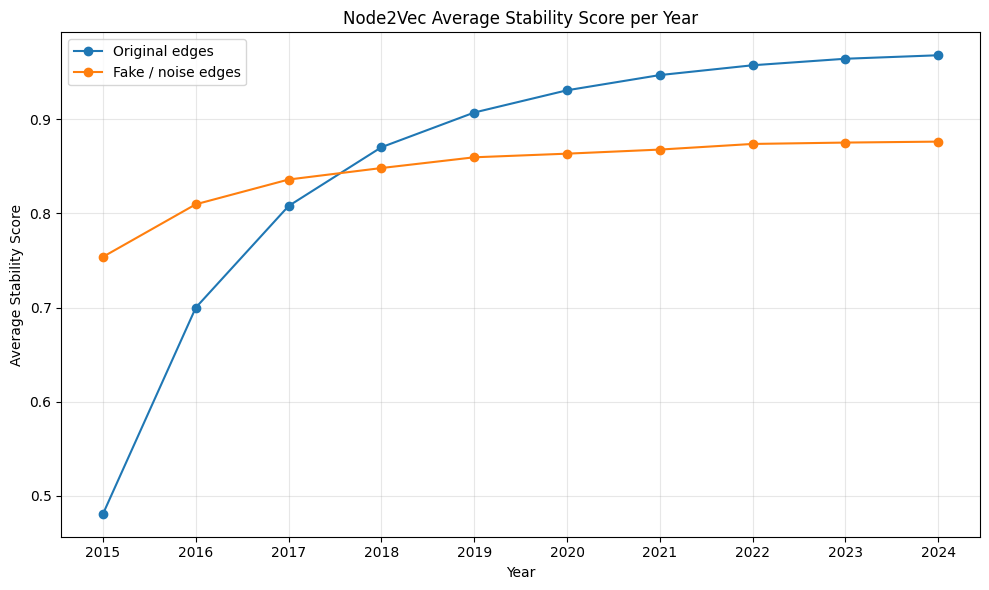

Saved: /content/gdrive/MyDrive/Final_project/visualization_results/node2vec_average_stability_score_per_year.png


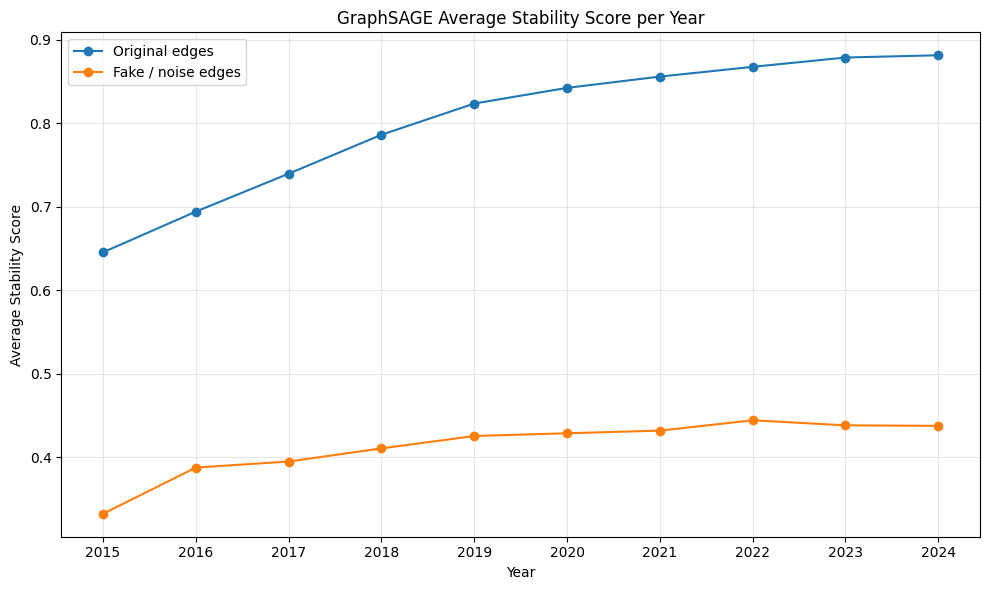

Saved: /content/gdrive/MyDrive/Final_project/visualization_results/graphsage_average_stability_score_per_year.png


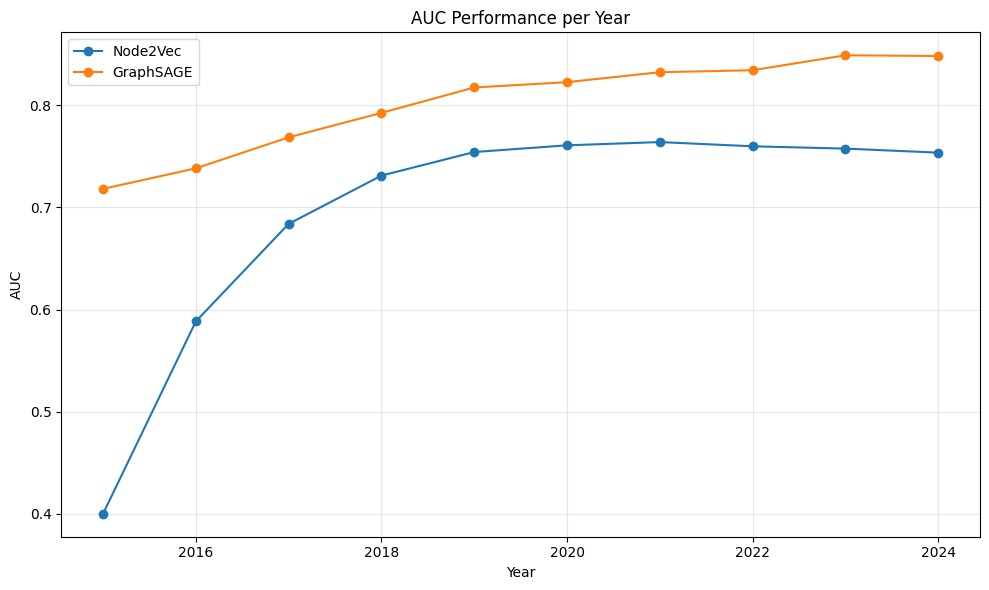

Saved: /content/gdrive/MyDrive/Final_project/visualization_results/auc_per_year_node2vec_vs_graphsage.png


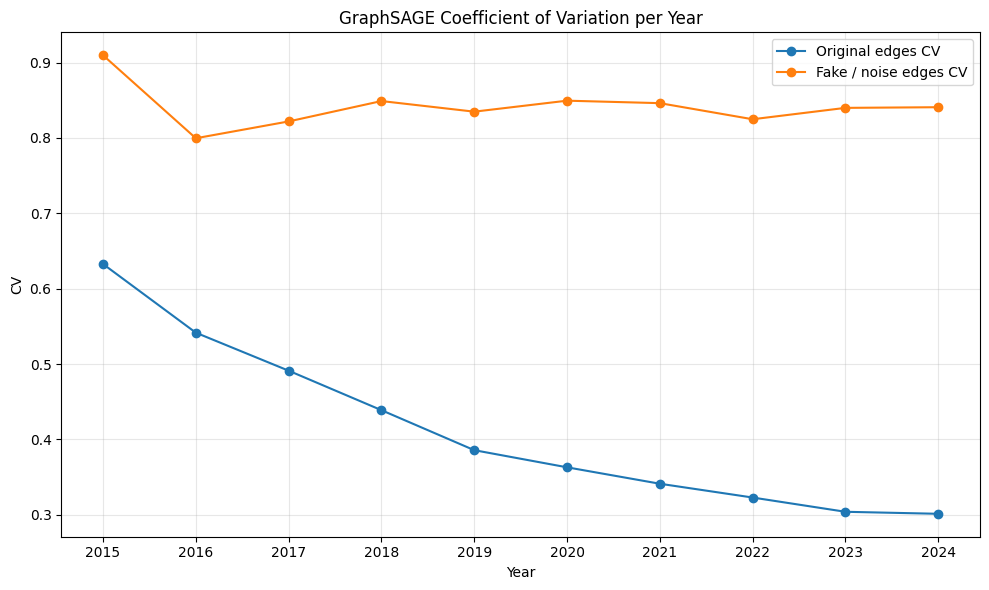

Saved: /content/gdrive/MyDrive/Final_project/visualization_results/graphsage_cv_per_year.png


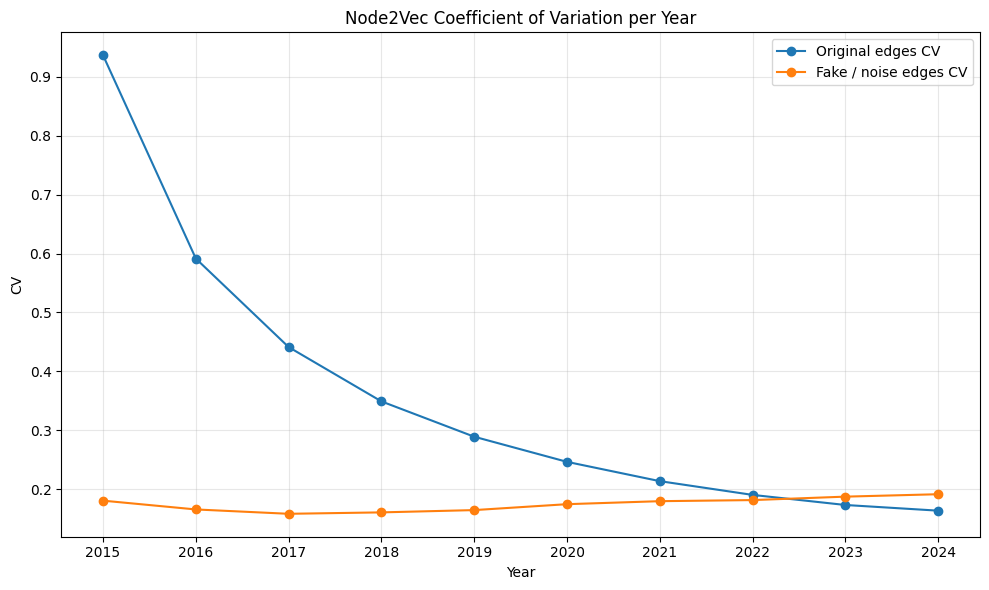

Saved: /content/gdrive/MyDrive/Final_project/visualization_results/node2vec_cv_per_year.png
Visualization dataframes were removed from RAM.


In [ ]:
# ==============================================================================
# Results Visualization - Node2Vec and GraphSAGE
# Creates and saves main result graphs
# ==============================================================================
def read_csv_if_exists(file_path):
    # Read CSV file only if it exists.
    if os.path.exists(file_path):
        return pd.read_csv(file_path)
    else:
        print(f"Missing file: {file_path}")
        return None

def save_plot(filename):
    # Save the current plot to the visualization folder.
    output_path = os.path.join(VISUALIZATION_DIR, filename)

    plt.tight_layout()
    plt.savefig(output_path, dpi=300, bbox_inches="tight")
    plt.show()

    # Close the figure to free RAM.
    plt.close()

    gc.collect()

    print("Saved:", output_path)


# ------------------------------------------------------------------------------
# Load summary files
# ------------------------------------------------------------------------------

# Main yearly summaries for Node2Vec and GraphSAGE.
node2vec_summary_file = os.path.join(
    NODE2VEC_RESULTS_DIR,
    "node2vec_all_years_summary.csv"
)

graphsage_summary_file = os.path.join(
    GRAPHSAGE_RESULTS_DIR,
    "all_years_summary.csv"
)

# CV result files for both models.
node2vec_cv_file = os.path.join(
    NODE2VEC_RESULTS_DIR,
    "node2vec_detailed_cv_per_year_from_db.csv"
)

graphsage_cv_file = os.path.join(
    GRAPHSAGE_RESULTS_DIR,
    "graphsage_detailed_cv_per_year.csv"
)

# Load files if available.
node2vec_summary = read_csv_if_exists(node2vec_summary_file)
graphsage_summary = read_csv_if_exists(graphsage_summary_file)
node2vec_cv = read_csv_if_exists(node2vec_cv_file)
graphsage_cv = read_csv_if_exists(graphsage_cv_file)


# ==============================================================================
# 1. Average Stability Score per Year - Node2Vec
# ==============================================================================

if node2vec_summary is not None:
    plt.figure(figsize=(10, 6))

    # Plot average stability of original edges.
    plt.plot(
        node2vec_summary["year"],
        node2vec_summary["avg_original_score"],
        marker="o",
        label="Original edges"
    )

    # Plot average stability of injected noise edges.
    plt.plot(
        node2vec_summary["year"],
        node2vec_summary["avg_fake_score"],
        marker="o",
        label="Fake / noise edges"
    )

    plt.title("Node2Vec Average Stability Score per Year")
    plt.xlabel("Year")
    plt.ylabel("Average Stability Score")
    plt.xticks(node2vec_summary["year"])
    plt.grid(True, alpha=0.3)
    plt.legend()

    save_plot("node2vec_average_stability_score_per_year.png")


# ==============================================================================
# 2. Average Stability Score per Year - GraphSAGE
# ==============================================================================

if graphsage_summary is not None:
    plt.figure(figsize=(10, 6))

    # Plot original vs noise stability for GraphSAGE.
    plt.plot(
        graphsage_summary["year"],
        graphsage_summary["avg_original_score"],
        marker="o",
        label="Original edges"
    )

    plt.plot(
        graphsage_summary["year"],
        graphsage_summary["avg_fake_score"],
        marker="o",
        label="Fake / noise edges"
    )

    plt.title("GraphSAGE Average Stability Score per Year")
    plt.xlabel("Year")
    plt.ylabel("Average Stability Score")
    plt.xticks(graphsage_summary["year"])
    plt.grid(True, alpha=0.3)
    plt.legend()

    save_plot("graphsage_average_stability_score_per_year.png")


# ==============================================================================
# 3. AUC per Year - Node2Vec vs GraphSAGE
# ==============================================================================

plt.figure(figsize=(10, 6))

has_auc_plot = False

# Plot Node2Vec AUC if available.
if node2vec_summary is not None and "auc" in node2vec_summary.columns:
    plt.plot(
        node2vec_summary["year"],
        node2vec_summary["auc"],
        marker="o",
        label="Node2Vec"
    )
    has_auc_plot = True

# Plot GraphSAGE AUC if available.
if graphsage_summary is not None and "auc" in graphsage_summary.columns:
    plt.plot(
        graphsage_summary["year"],
        graphsage_summary["auc"],
        marker="o",
        label="GraphSAGE"
    )
    has_auc_plot = True

# Save AUC comparison plot only if data exists.
if has_auc_plot:
    plt.title("AUC Performance per Year")
    plt.xlabel("Year")
    plt.ylabel("AUC")
    plt.grid(True, alpha=0.3)
    plt.legend()
    save_plot("auc_per_year_node2vec_vs_graphsage.png")
else:
    plt.close()
    print("AUC plot was not created because AUC columns were not found.")

# ==============================================================================
# 4. CV per Year - GraphSAGE
# ==============================================================================

if graphsage_cv is not None:
    plt.figure(figsize=(10, 6))

    # Plot CV of original and noise edges for GraphSAGE.
    plt.plot(
        graphsage_cv["year"],
        graphsage_cv["original_cv"],
        marker="o",
        label="Original edges CV"
    )

    plt.plot(
        graphsage_cv["year"],
        graphsage_cv["fake_cv"],
        marker="o",
        label="Fake / noise edges CV"
    )

    plt.title("GraphSAGE Coefficient of Variation per Year")
    plt.xlabel("Year")
    plt.ylabel("CV")
    plt.xticks(graphsage_cv["year"])
    plt.grid(True, alpha=0.3)
    plt.legend()

    save_plot("graphsage_cv_per_year.png")

# ==============================================================================
# 5. CV per Year - Node2Vec
# ==============================================================================

if node2vec_cv is not None:
    plt.figure(figsize=(10, 6))

    # Plot CV of original and noise edges for Node2Vec.
    plt.plot(
        node2vec_cv["year"],
        node2vec_cv["original_cv"],
        marker="o",
        label="Original edges CV"
    )

    plt.plot(
        node2vec_cv["year"],
        node2vec_cv["fake_cv"],
        marker="o",
        label="Fake / noise edges CV"
    )

    plt.title("Node2Vec Coefficient of Variation per Year")
    plt.xlabel("Year")
    plt.ylabel("CV")
    plt.xticks(node2vec_cv["year"])
    plt.grid(True, alpha=0.3)
    plt.legend()

    save_plot("node2vec_cv_per_year.png")

# Free loaded summary dataframes from RAM.
for var_name in ["node2vec_summary", "graphsage_summary", "node2vec_cv", "graphsage_cv"]:
    if var_name in globals():
        del globals()[var_name]

gc.collect()

print("Visualization dataframes were removed from RAM.")


## GraphSAGE Stability Distributions

Creates yearly histograms of GraphSAGE stability scores to compare the distribution of original edges and injected noise edges.



Processing GraphSAGE year 2015
Original scores: 10353
Injected scores: 523


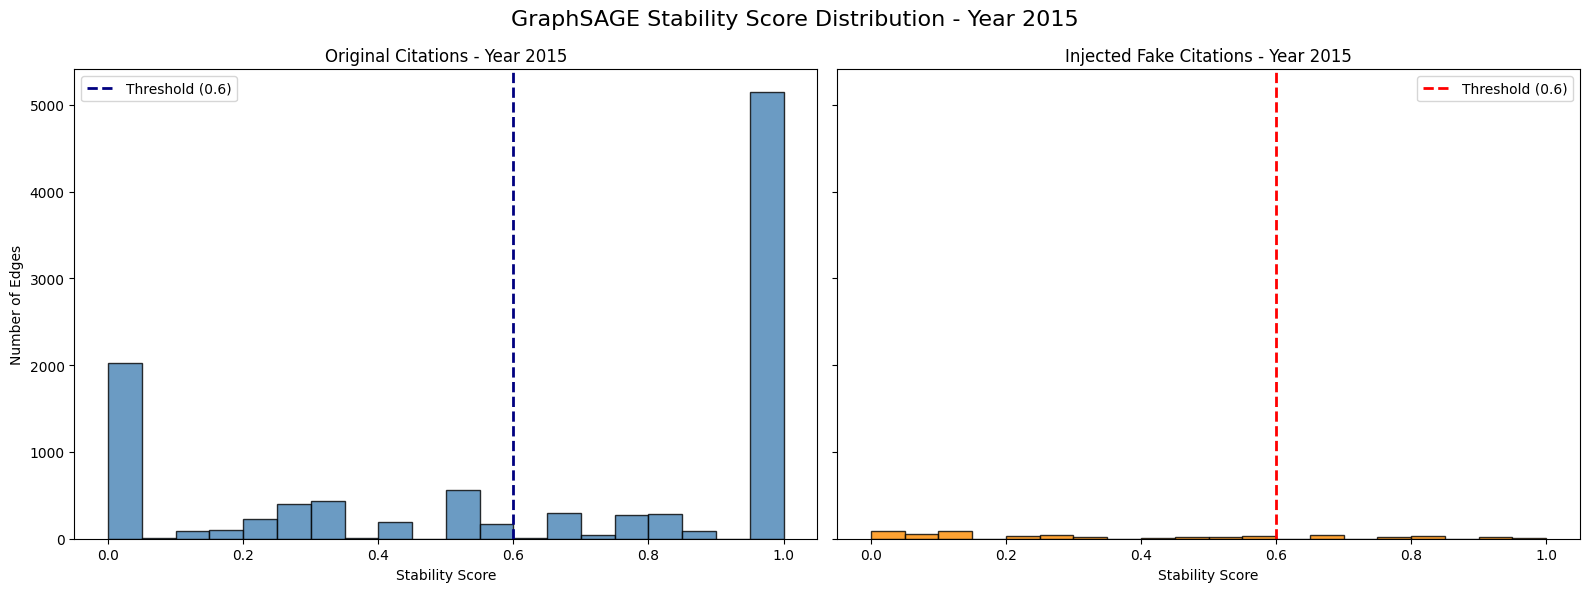

Saved: /content/gdrive/MyDrive/Final_project/visualization_results/GraphSAGE_histograms_per_year/graphsage_side_by_side_distribution_2015.png

Processing GraphSAGE year 2016
Original scores: 56304
Injected scores: 2848


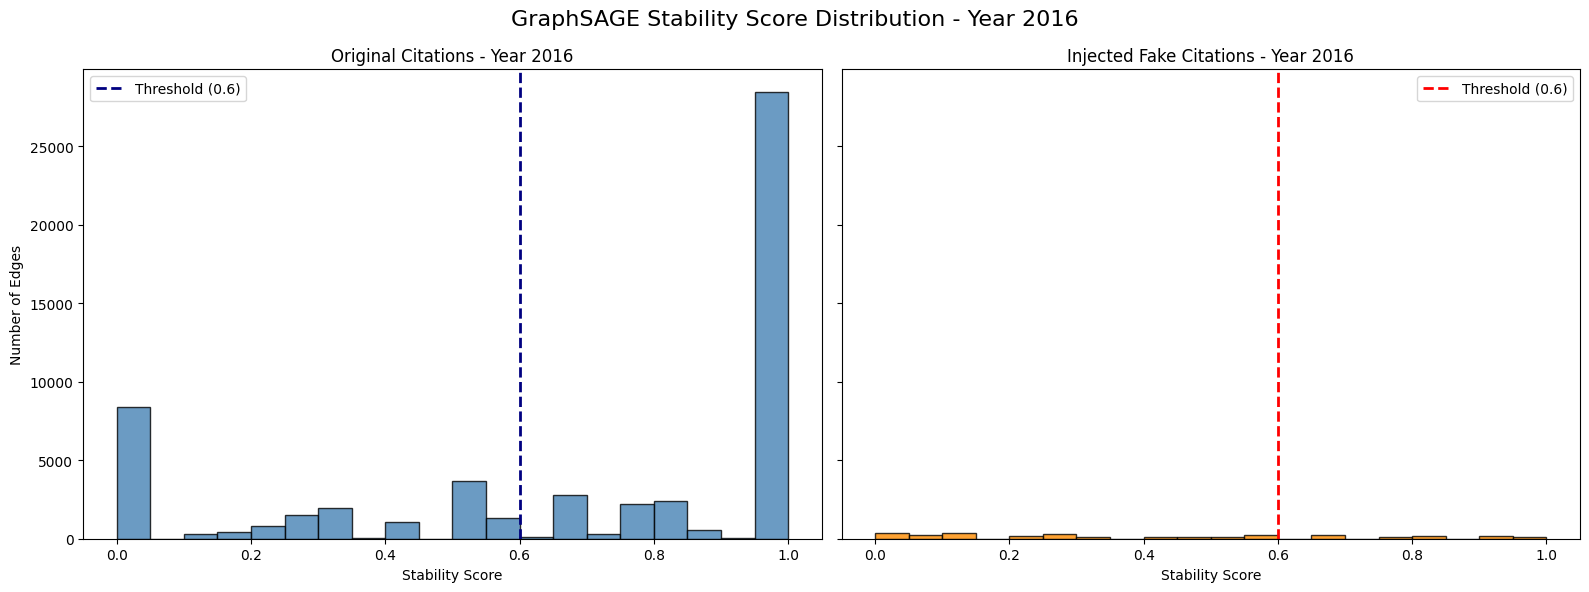

Saved: /content/gdrive/MyDrive/Final_project/visualization_results/GraphSAGE_histograms_per_year/graphsage_side_by_side_distribution_2016.png

Processing GraphSAGE year 2017
Original scores: 148949
Injected scores: 7532


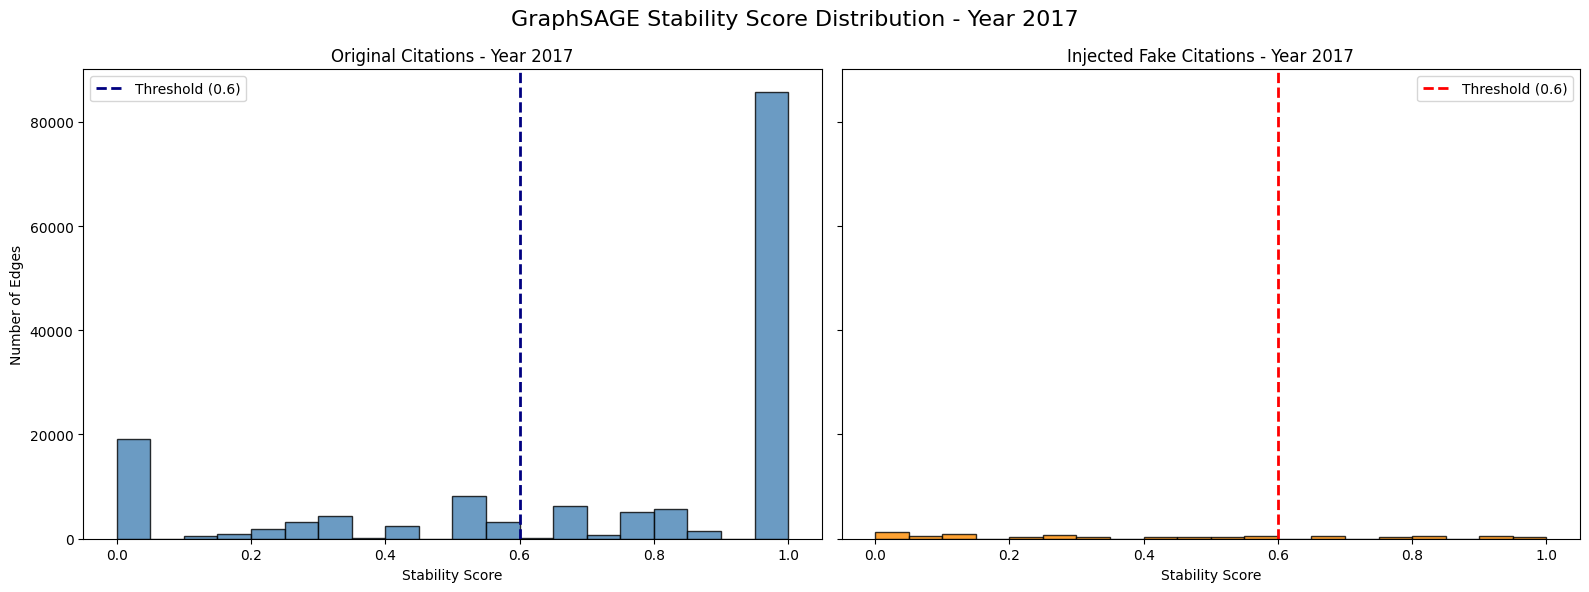

Saved: /content/gdrive/MyDrive/Final_project/visualization_results/GraphSAGE_histograms_per_year/graphsage_side_by_side_distribution_2017.png

Processing GraphSAGE year 2018
Original scores: 307096
Injected scores: 15531


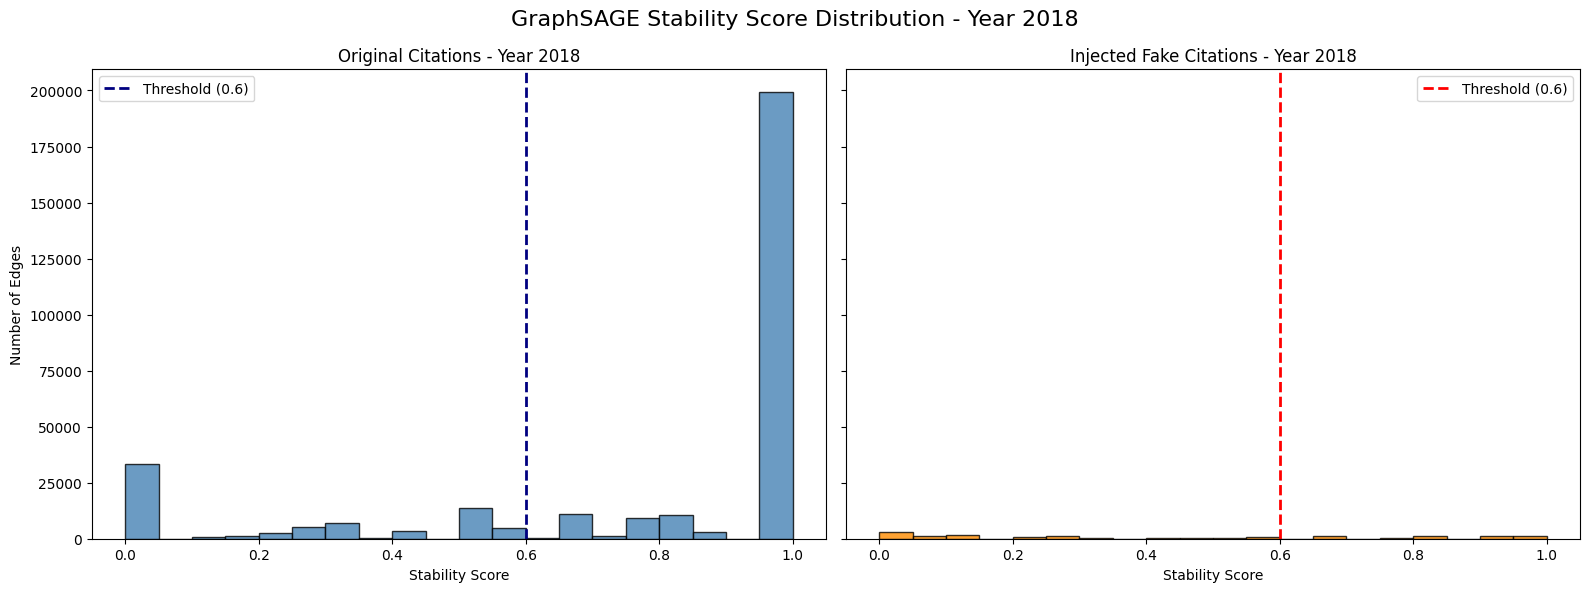

Saved: /content/gdrive/MyDrive/Final_project/visualization_results/GraphSAGE_histograms_per_year/graphsage_side_by_side_distribution_2018.png

Processing GraphSAGE year 2019
Original scores: 550528
Injected scores: 27843


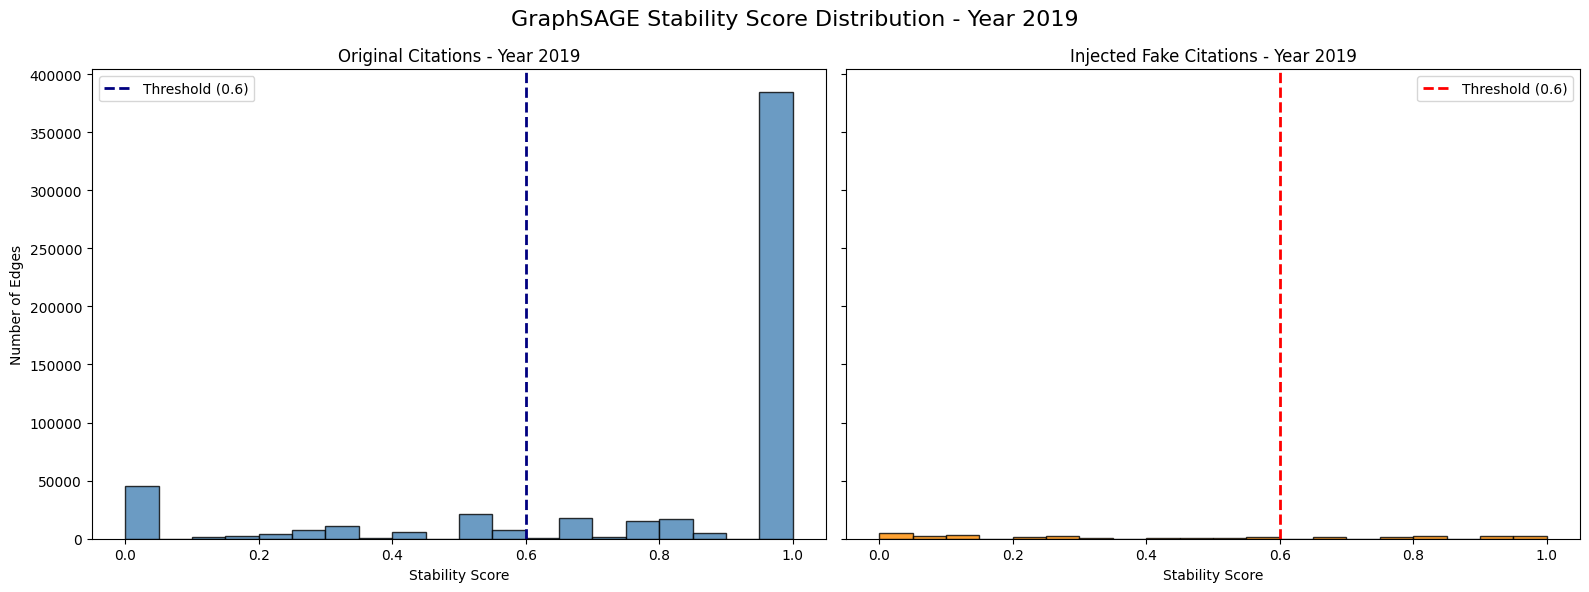

Saved: /content/gdrive/MyDrive/Final_project/visualization_results/GraphSAGE_histograms_per_year/graphsage_side_by_side_distribution_2019.png

Processing GraphSAGE year 2020
Original scores: 899824
Injected scores: 45521


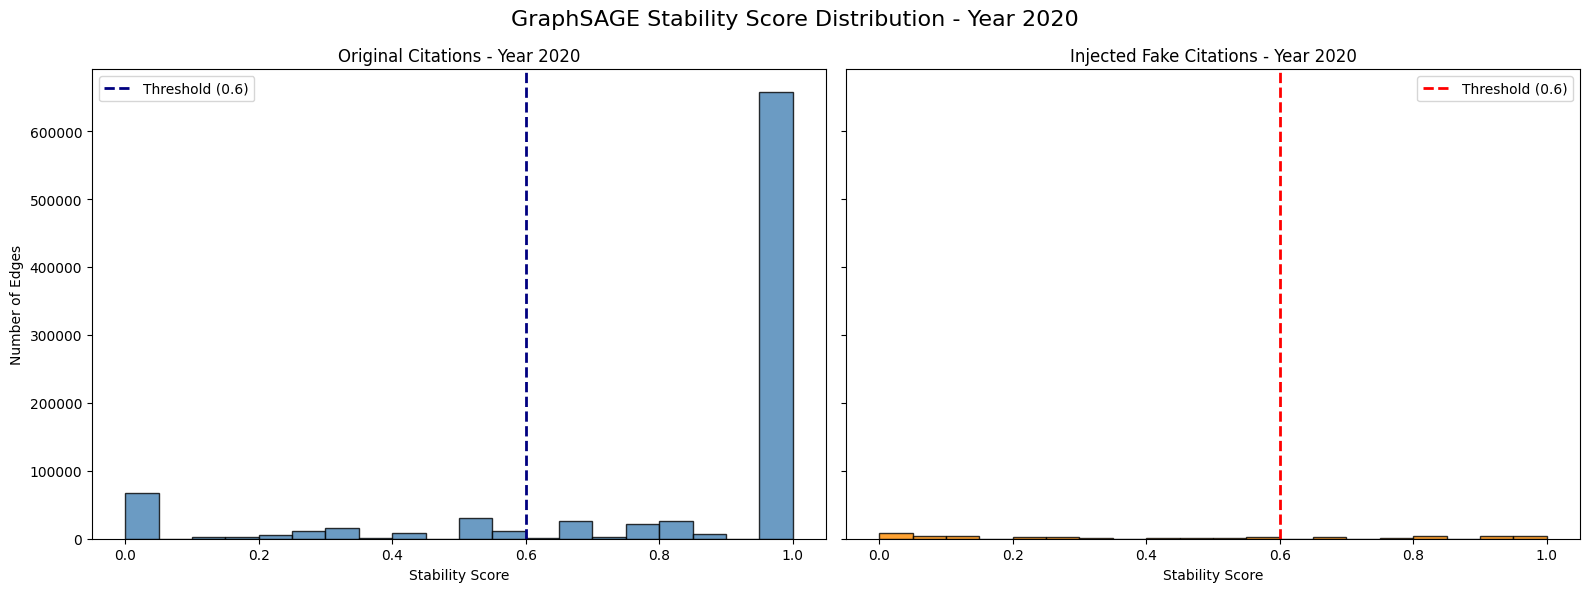

Saved: /content/gdrive/MyDrive/Final_project/visualization_results/GraphSAGE_histograms_per_year/graphsage_side_by_side_distribution_2020.png

Processing GraphSAGE year 2021
Original scores: 1396372
Injected scores: 70631


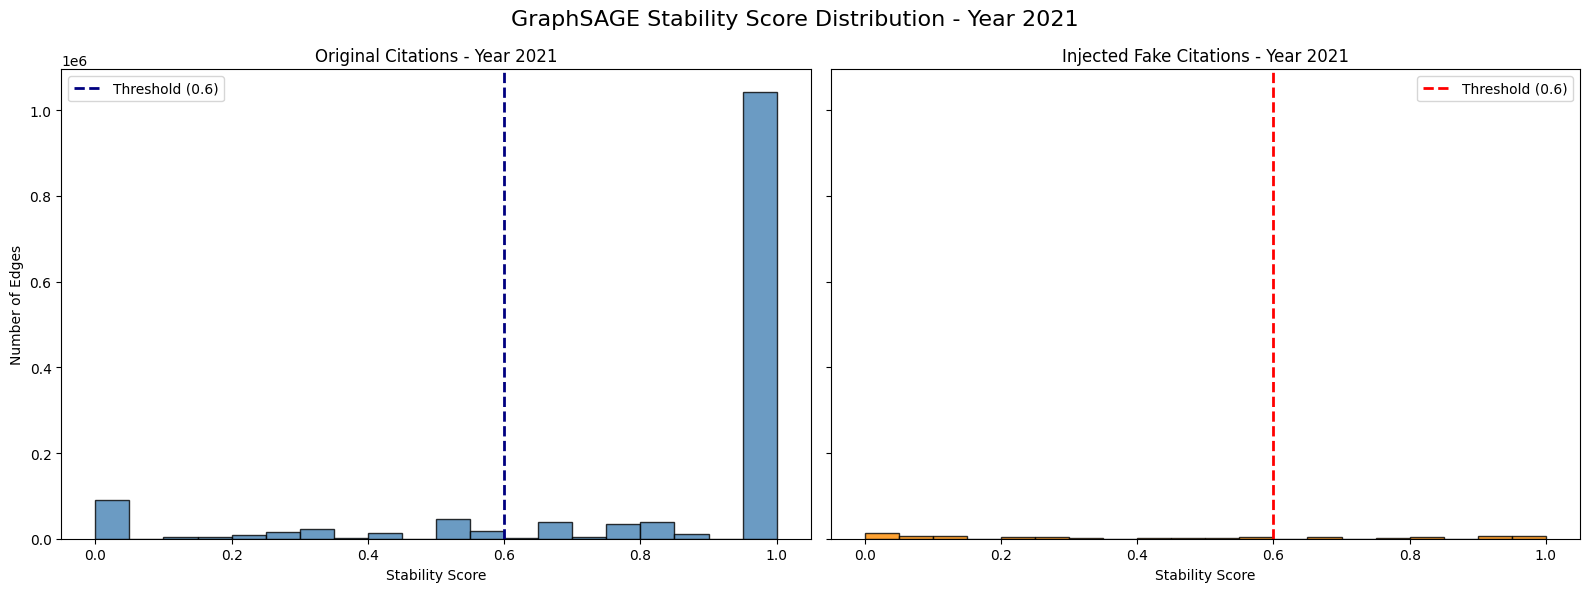

Saved: /content/gdrive/MyDrive/Final_project/visualization_results/GraphSAGE_histograms_per_year/graphsage_side_by_side_distribution_2021.png

Processing GraphSAGE year 2022
Original scores: 2002756
Injected scores: 101304


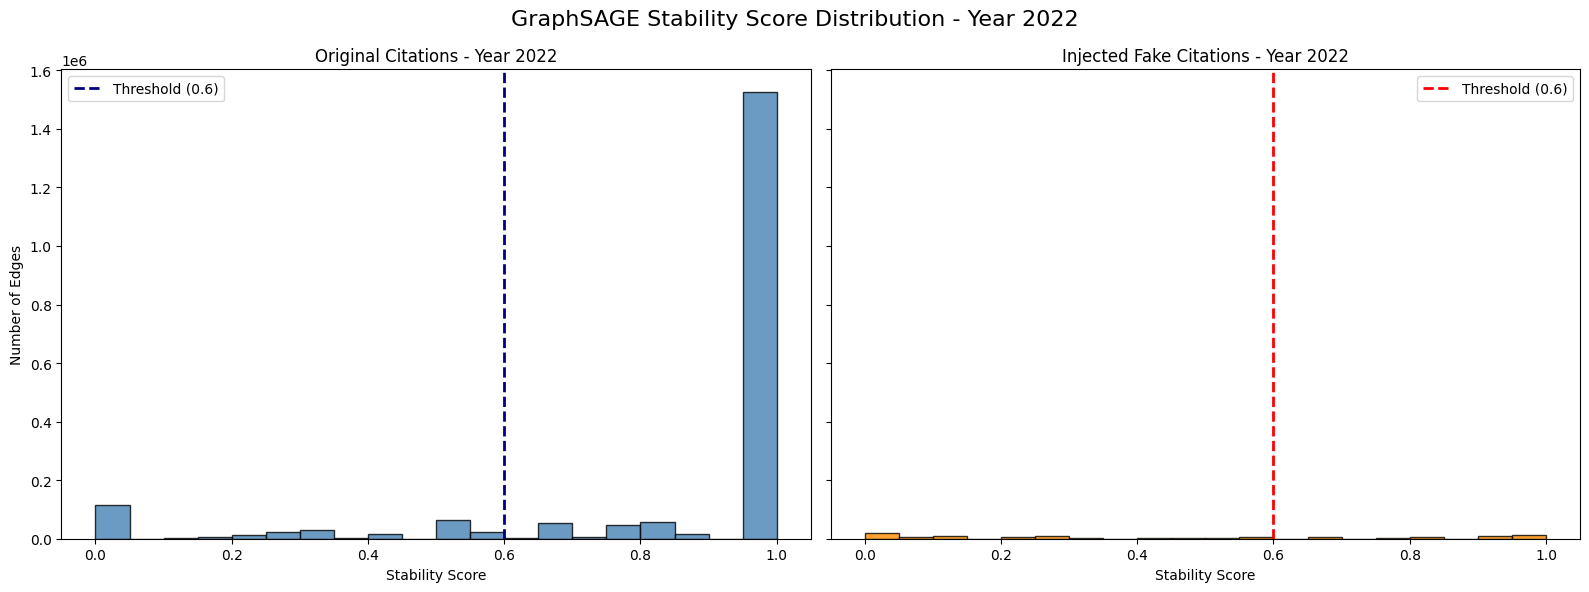

Saved: /content/gdrive/MyDrive/Final_project/visualization_results/GraphSAGE_histograms_per_year/graphsage_side_by_side_distribution_2022.png

Processing GraphSAGE year 2023
Original scores: 2760171
Injected scores: 139613


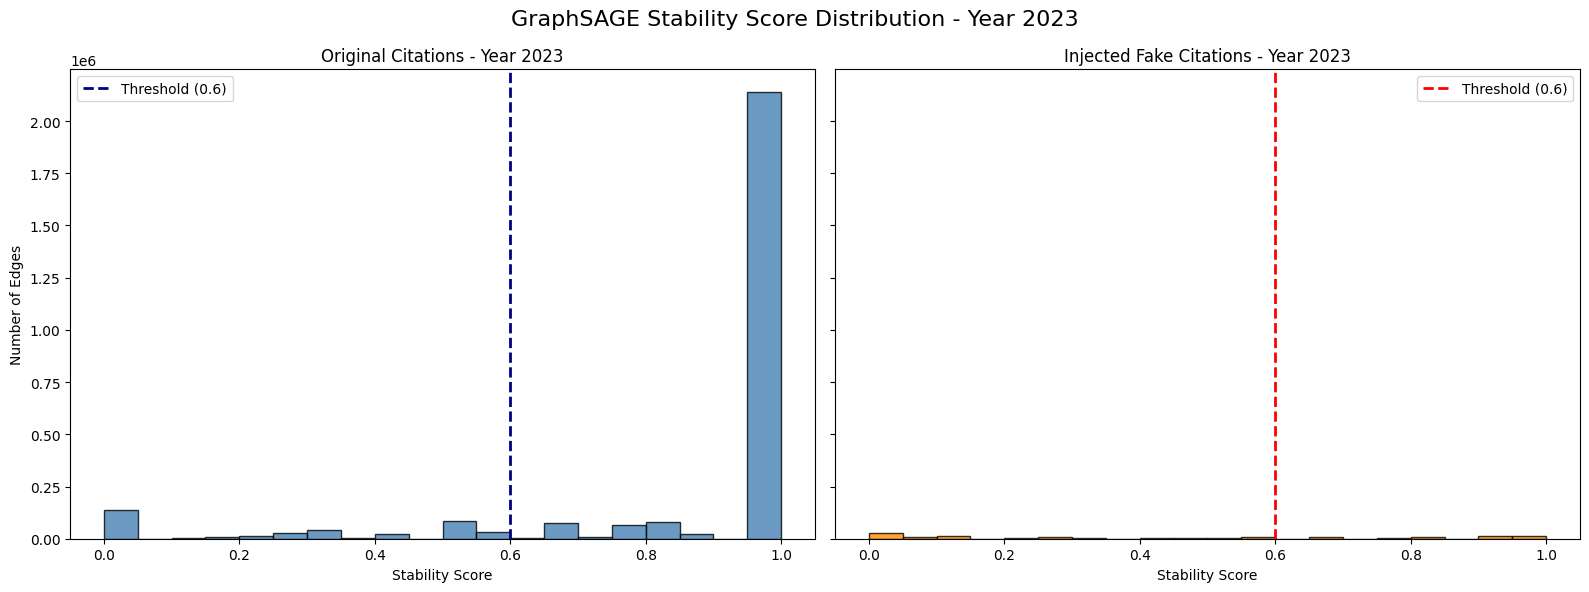

Saved: /content/gdrive/MyDrive/Final_project/visualization_results/GraphSAGE_histograms_per_year/graphsage_side_by_side_distribution_2023.png

Processing GraphSAGE year 2024
Original scores: 3527727
Injected scores: 178434


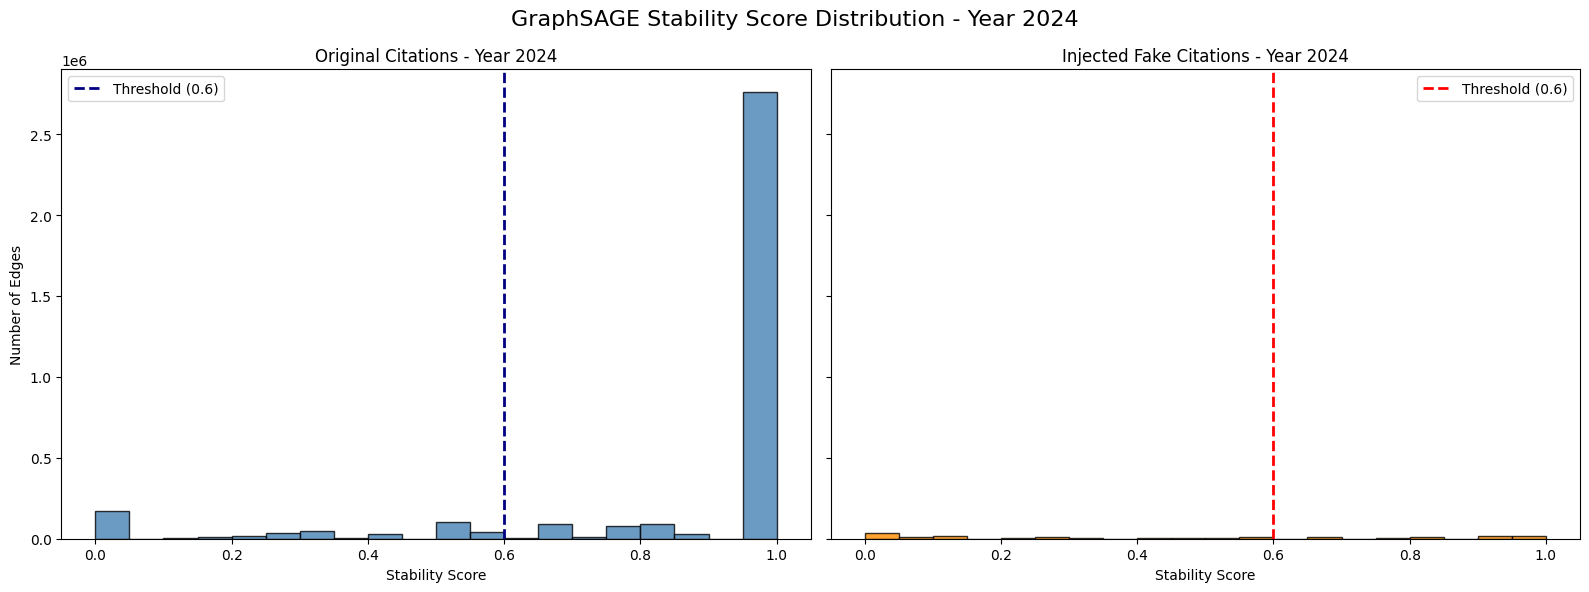

Saved: /content/gdrive/MyDrive/Final_project/visualization_results/GraphSAGE_histograms_per_year/graphsage_side_by_side_distribution_2024.png


In [ ]:
# Plot settings.
THRESHOLD_LINE = 0.6
BINS = 20

START_YEAR=2015
END_YEAR=2024

ORIGINAL_COLOR = "steelblue"
INJECTED_COLOR = "darkorange"


def normalize_edge(edge):
    # Normalize edge direction so (u, v) and (v, u) are treated the same.
    u, v = edge
    return tuple(sorted((str(u), str(v))))


# ----------------------------------------
# Create GraphSAGE side-by-side histograms per year
# ----------------------------------------
for year in range(START_YEAR, END_YEAR + 1):

    # Required files for this year.
    checkpoint_file = os.path.join(
        GRAPHSAGE_CHECKPOINT_DIR,
        f"graphsage_stability_checkpoint_{year}.pkl"
    )

    nodes_snapshot_file = os.path.join(
        SNAPSHOTS_DIR,
        f"nodes_snapshot_{year}.csv"
    )

    edges_snapshot_file = os.path.join(
        SNAPSHOTS_DIR,
        f"edges_snapshot_{year}.csv"
    )

    # Skip year if required files are missing.
    if not os.path.exists(checkpoint_file):
        print(f"Missing checkpoint for year {year}")
        continue

    if not os.path.exists(nodes_snapshot_file) or not os.path.exists(edges_snapshot_file):
        print(f"Missing snapshot files for year {year}")
        continue

    print(f"\nProcessing GraphSAGE year {year}")

    # Load saved removal and reconstruction counts.
    with open(checkpoint_file, "rb") as f:
        checkpoint = pickle.load(f)

    removal_counts_sage = checkpoint.get("removal_counts_sage", {})
    reconstruction_counts_sage = checkpoint.get("reconstruction_counts_sage", {})

    # Load yearly snapshot files.
    nodes_df_year = pd.read_csv(nodes_snapshot_file)
    edges_df_year = pd.read_csv(edges_snapshot_file)

    # Keep valid node IDs from the snapshot.
    valid_nodes = set(nodes_df_year["id"].astype(str))

    # Rebuild original edge set from the snapshot.
    original_set = set()
    for row in edges_df_year.itertuples(index=False):
        source = str(row.source)
        target = str(row.target)

        if source in valid_nodes and target in valid_nodes:
            original_set.add(normalize_edge((source, target)))

    # Calculate stability scores for original and injected edges.
    original_scores = []
    fake_scores = []

    for edge, removal_count in removal_counts_sage.items():
        if removal_count <= 0:
            continue

        norm_edge = normalize_edge(edge)

        # Stability = reconstructed times / removed times.
        score = reconstruction_counts_sage.get(edge, 0) / removal_count

        if norm_edge in original_set:
            original_scores.append(score)
        else:
            fake_scores.append(score)

    original_scores = pd.Series(original_scores).dropna()
    fake_scores = pd.Series(fake_scores).dropna()

    print(f"Original scores: {len(original_scores)}")
    print(f"Injected scores: {len(fake_scores)}")

    # Create side-by-side histograms.
    fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)

    # Original citation stability distribution.
    axes[0].hist(
        original_scores,
        bins=BINS,
        alpha=0.8,
        color=ORIGINAL_COLOR,
        edgecolor="black"
    )
    axes[0].axvline(
        THRESHOLD_LINE,
        color="navy",
        linestyle="--",
        linewidth=2,
        label=f"Threshold ({THRESHOLD_LINE})"
    )
    axes[0].set_title(f"Original Citations - Year {year}")
    axes[0].set_xlabel("Stability Score")
    axes[0].set_ylabel("Number of Edges")
    axes[0].legend()

    # Injected fake citation stability distribution.
    axes[1].hist(
        fake_scores,
        bins=BINS,
        alpha=0.8,
        color=INJECTED_COLOR,
        edgecolor="black"
    )
    axes[1].axvline(
        THRESHOLD_LINE,
        color="red",
        linestyle="--",
        linewidth=2,
        label=f"Threshold ({THRESHOLD_LINE})"
    )
    axes[1].set_title(f"Injected Fake Citations - Year {year}")
    axes[1].set_xlabel("Stability Score")
    axes[1].legend()

    fig.suptitle(f"GraphSAGE Stability Score Distribution - Year {year}", fontsize=16)

    # Save histogram image for this year.
    output_path = os.path.join(
        GRAPHSAGE_HIST_DIR,
        f"graphsage_side_by_side_distribution_{year}.png"
    )

    plt.tight_layout()
    plt.savefig(output_path, dpi=300, bbox_inches="tight")
    plt.show()

    print("Saved:", output_path)


    # Free RAM before processing the next year.
    plt.close(fig)

    del checkpoint
    del removal_counts_sage, reconstruction_counts_sage
    del nodes_df_year, edges_df_year
    del valid_nodes, original_set
    del original_scores, fake_scores
    del fig, axes

    gc.collect()

## Node2Vec Stability Distributions

Creates yearly histograms of Node2Vec stability scores using the SQLite database to examine the separation between original and injected noise edges.


Node2Vec rows loaded: 12249590


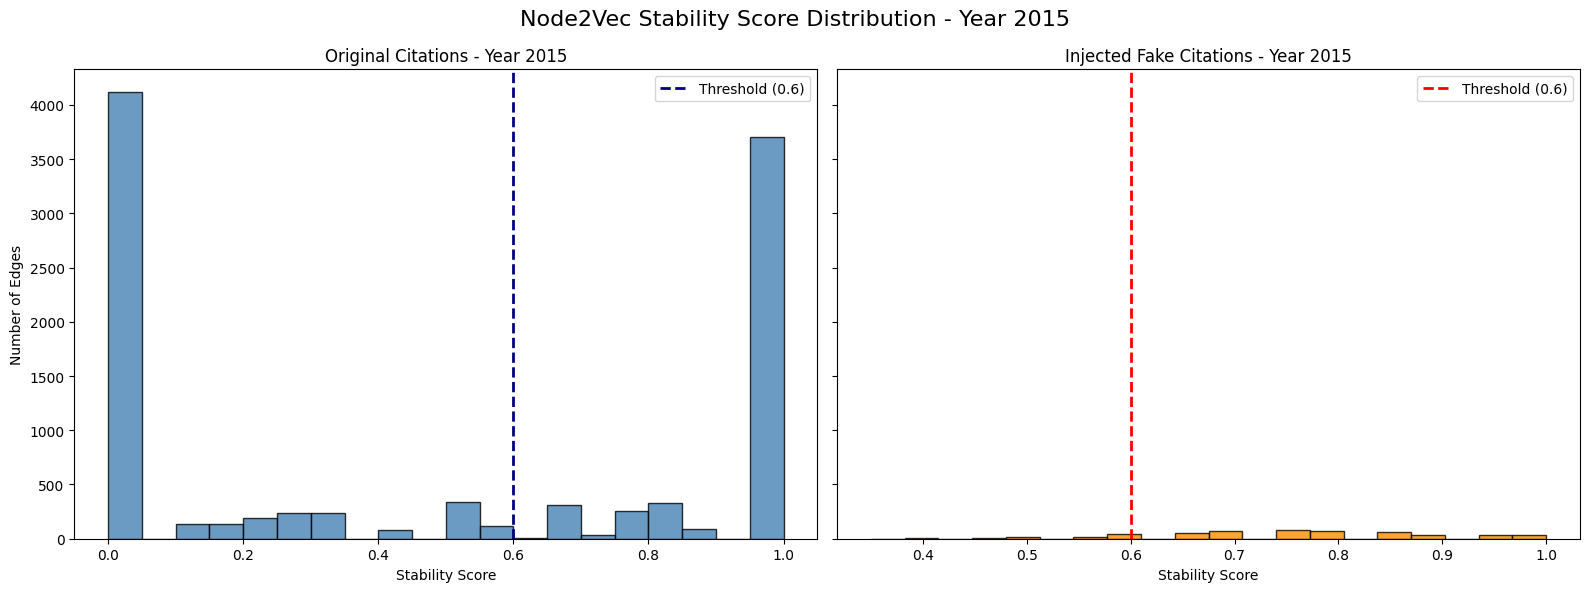

Saved: /content/gdrive/MyDrive/Final_project/visualization_results/Node2Vec_histograms_per_year/node2vec_side_by_side_distribution_2015.png


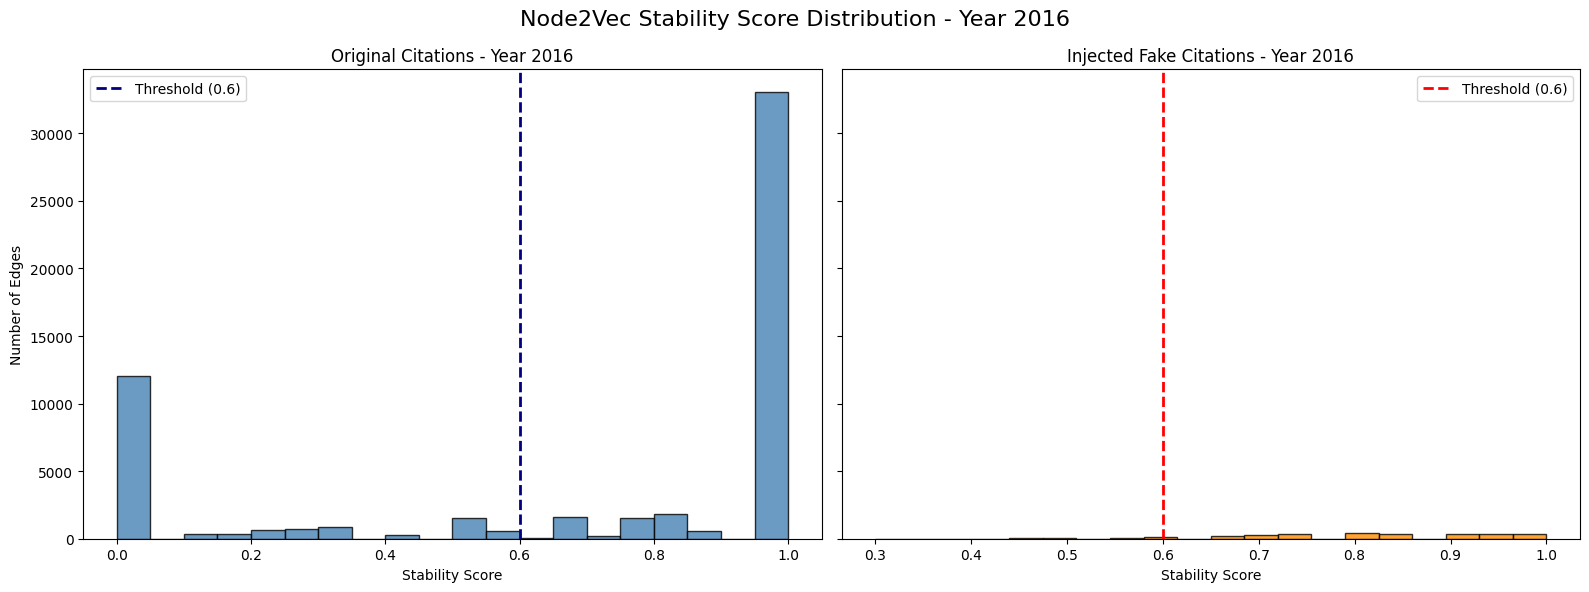

Saved: /content/gdrive/MyDrive/Final_project/visualization_results/Node2Vec_histograms_per_year/node2vec_side_by_side_distribution_2016.png


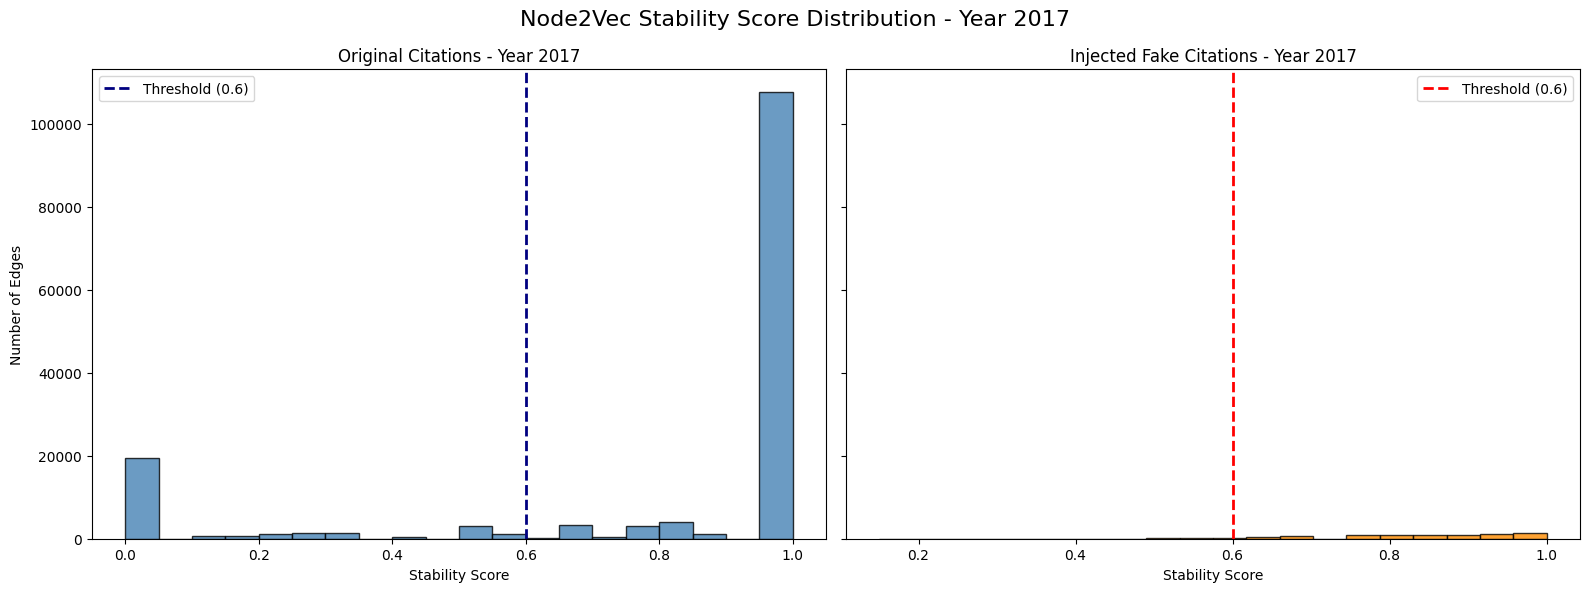

Saved: /content/gdrive/MyDrive/Final_project/visualization_results/Node2Vec_histograms_per_year/node2vec_side_by_side_distribution_2017.png


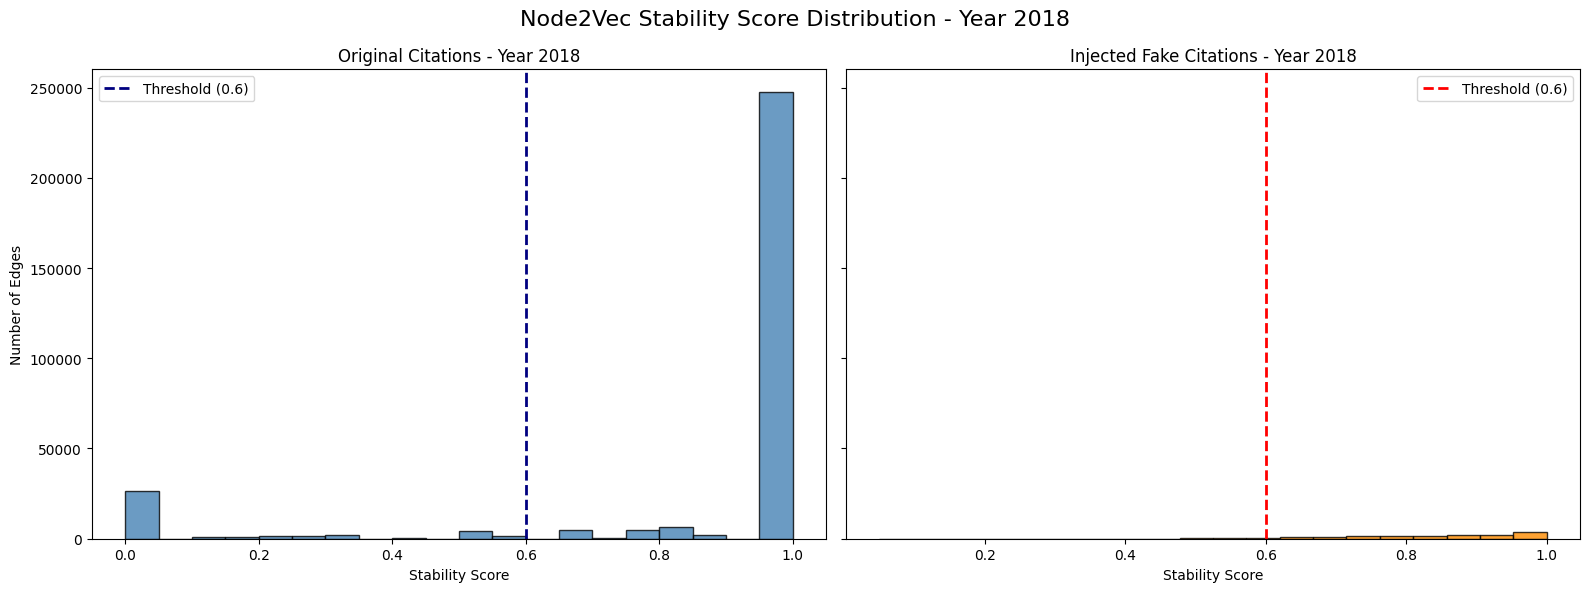

Saved: /content/gdrive/MyDrive/Final_project/visualization_results/Node2Vec_histograms_per_year/node2vec_side_by_side_distribution_2018.png


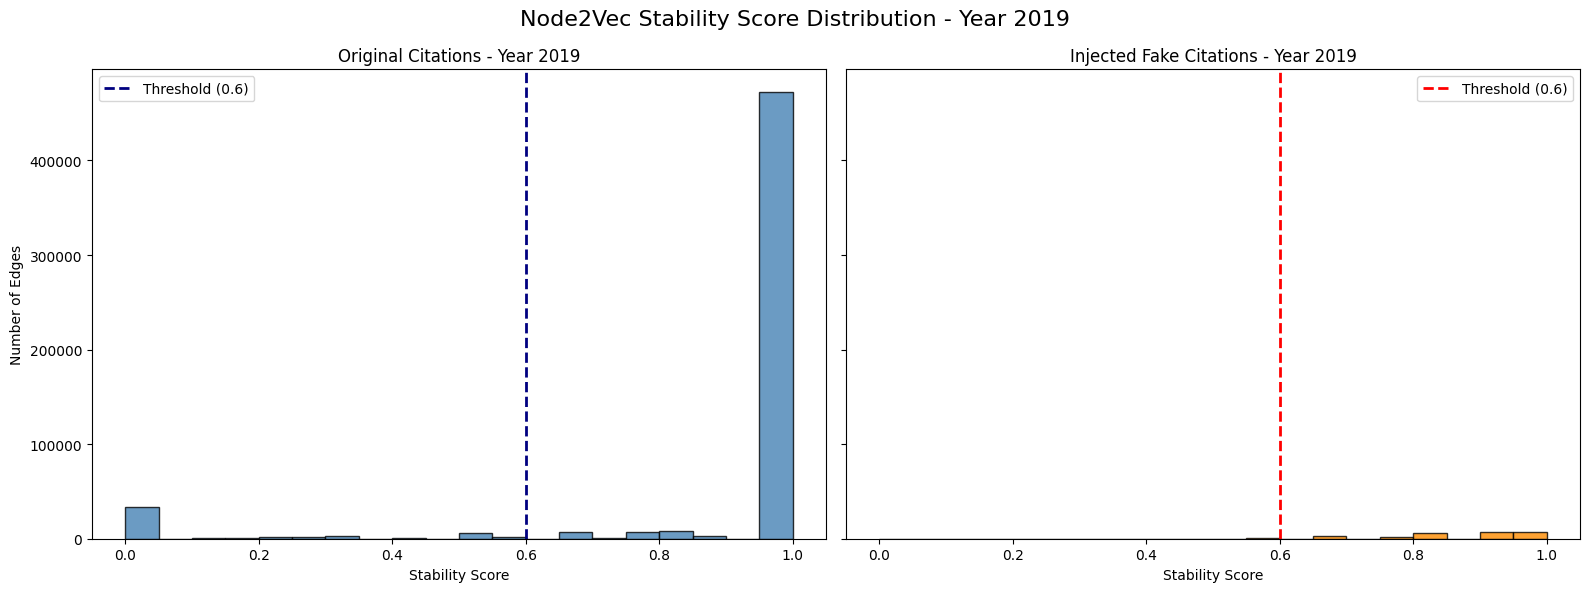

Saved: /content/gdrive/MyDrive/Final_project/visualization_results/Node2Vec_histograms_per_year/node2vec_side_by_side_distribution_2019.png


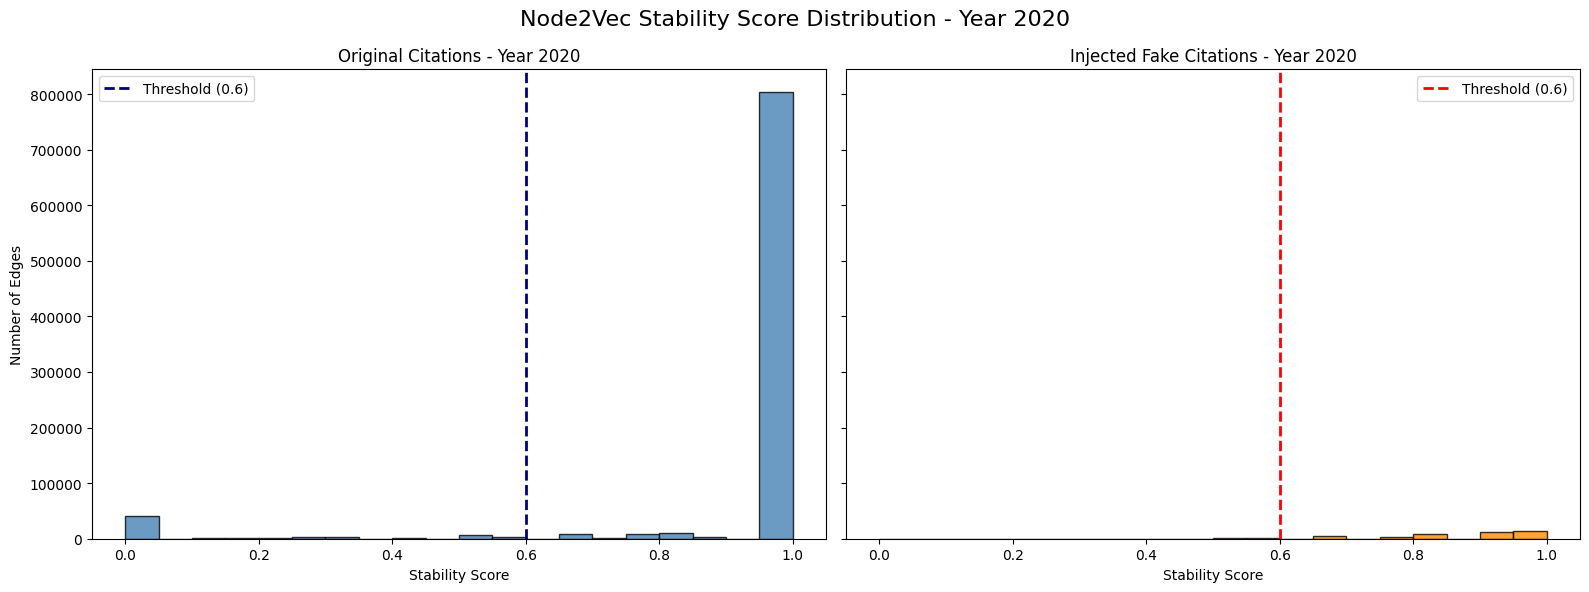

Saved: /content/gdrive/MyDrive/Final_project/visualization_results/Node2Vec_histograms_per_year/node2vec_side_by_side_distribution_2020.png


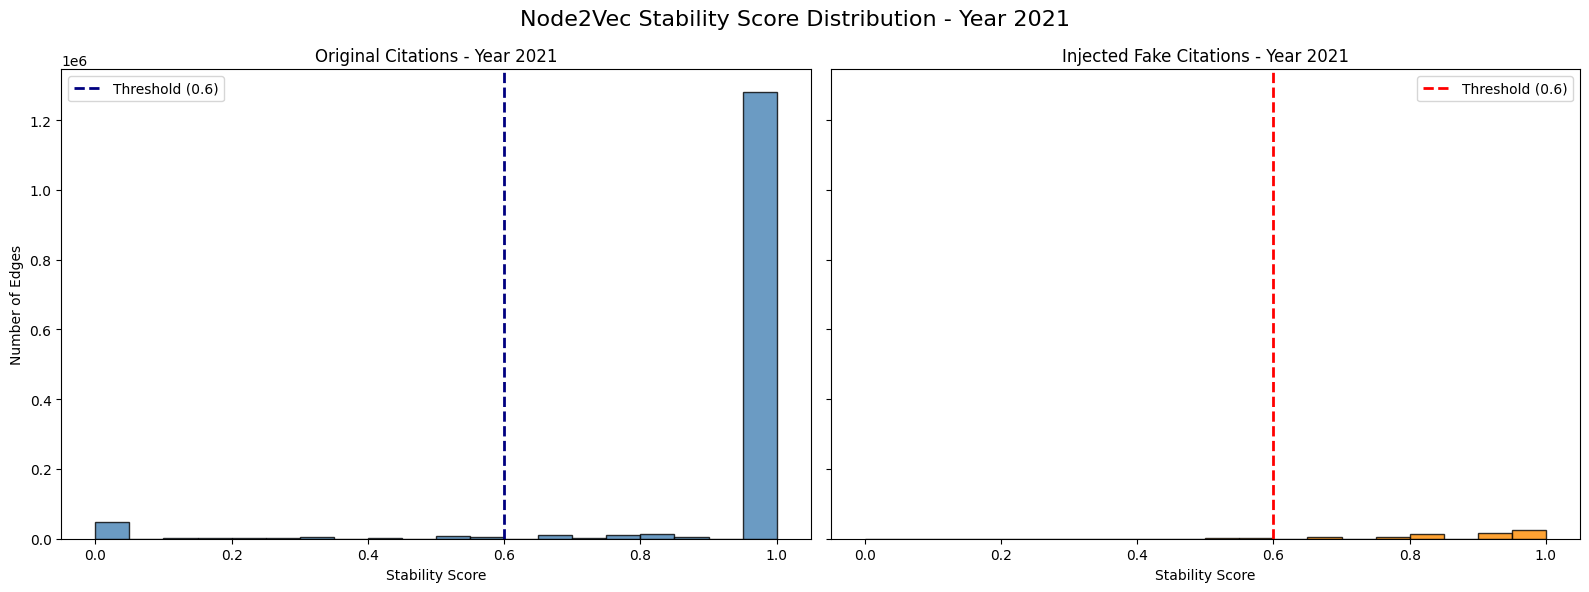

Saved: /content/gdrive/MyDrive/Final_project/visualization_results/Node2Vec_histograms_per_year/node2vec_side_by_side_distribution_2021.png


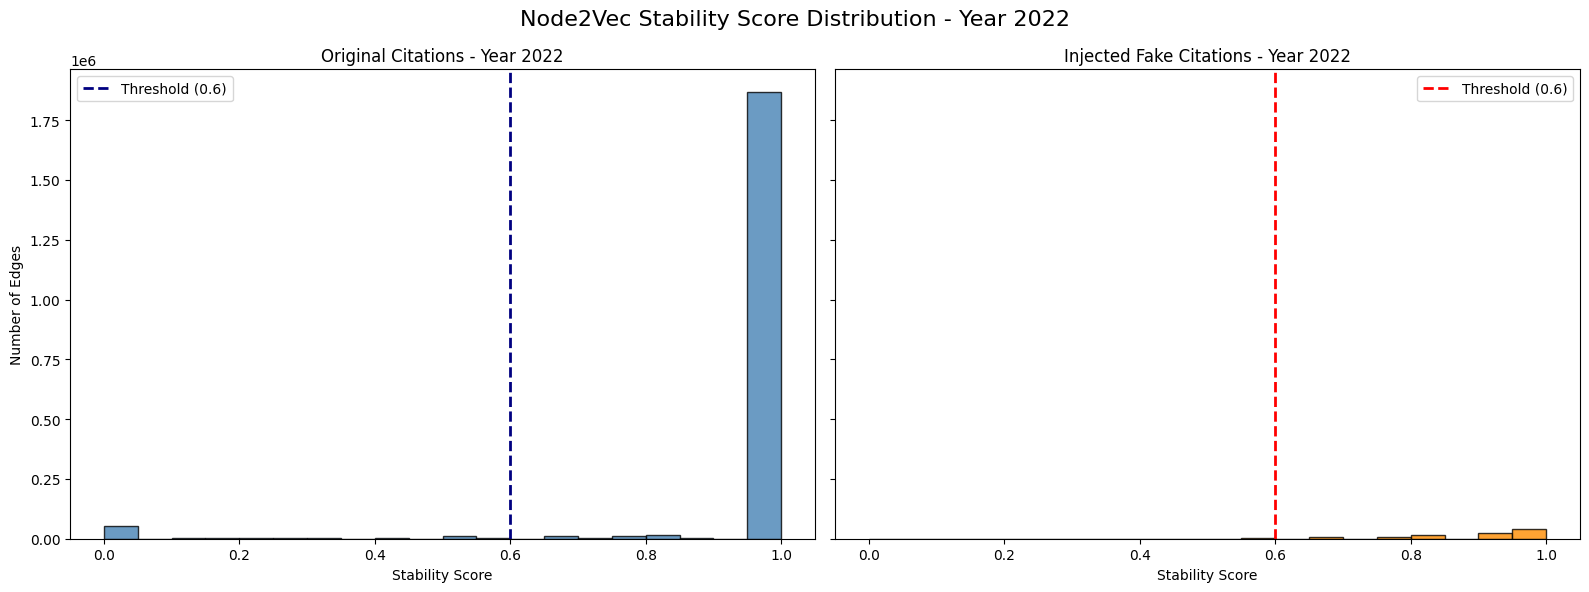

Saved: /content/gdrive/MyDrive/Final_project/visualization_results/Node2Vec_histograms_per_year/node2vec_side_by_side_distribution_2022.png


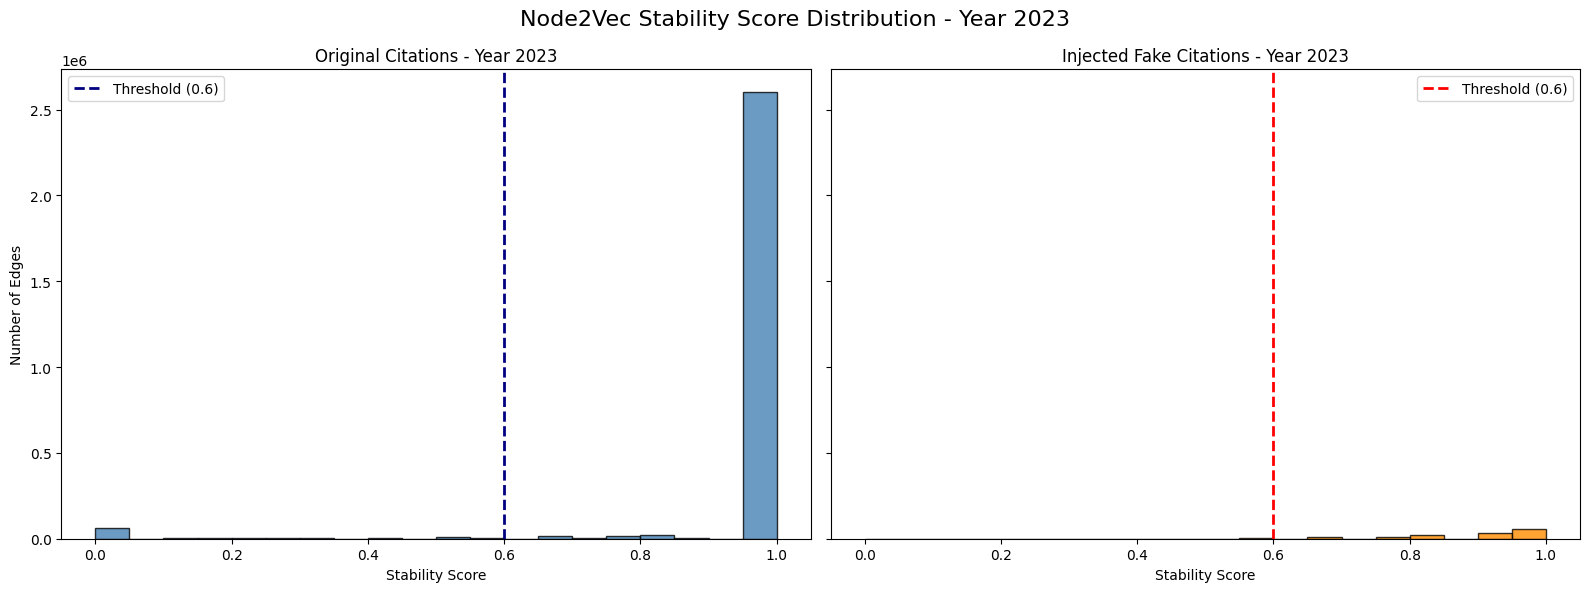

Saved: /content/gdrive/MyDrive/Final_project/visualization_results/Node2Vec_histograms_per_year/node2vec_side_by_side_distribution_2023.png


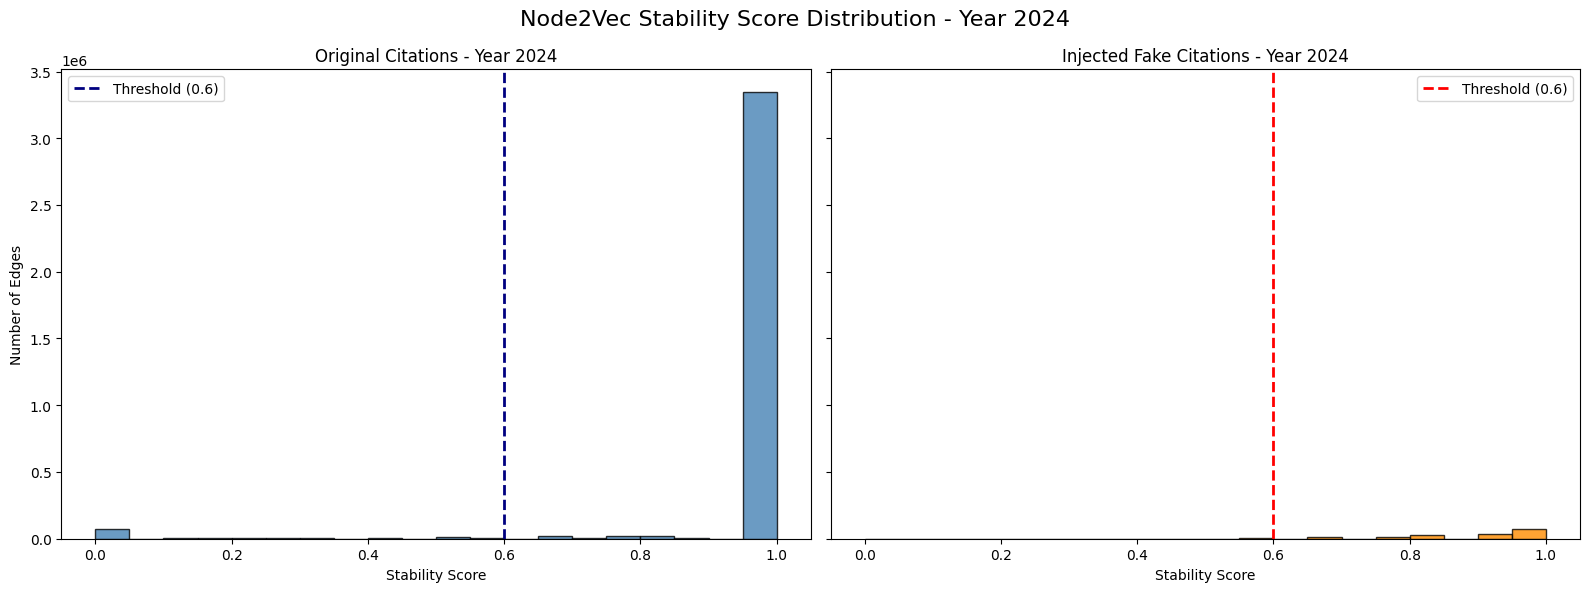

Saved: /content/gdrive/MyDrive/Final_project/visualization_results/Node2Vec_histograms_per_year/node2vec_side_by_side_distribution_2024.png
Node2Vec histogram data was removed from RAM.


In [ ]:
# Plot settings.
THRESHOLD_LINE = 0.6
BINS = 20

ORIGINAL_COLOR = "steelblue"
INJECTED_COLOR = "darkorange"

# ----------------------------------------
# Load Node2Vec stability scores from SQLite
# ----------------------------------------

# Open the SQLite database saved from Node2Vec runs.
conn = sqlite3.connect(NODE2VEC_DB_FILE_DRIVE)

query = """
    SELECT year, edge_type, removal_count, reconstruction_count
    FROM edge_counts
    WHERE removal_count > 0
"""

# Read edge counts from the database.
df_n2v = pd.read_sql_query(query, conn)
conn.close()

# Keep only original and noise edges.
df_n2v = df_n2v[df_n2v["edge_type"].isin(["original", "noise"])].copy()

# Calculate stability score for each edge.
df_n2v["stability_score"] = df_n2v["reconstruction_count"] / df_n2v["removal_count"]

print("Node2Vec rows loaded:", len(df_n2v))

# ----------------------------------------
# Create side-by-side histograms per year
# ----------------------------------------
for year in sorted(df_n2v["year"].unique()):
    year_df = df_n2v[df_n2v["year"] == year]

    # Separate original and injected/noise edge scores.
    original_scores = year_df[year_df["edge_type"] == "original"]["stability_score"].dropna()
    noise_scores = year_df[year_df["edge_type"] == "noise"]["stability_score"].dropna()

    # Create two histograms side by side.
    fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)

    # Original citation stability distribution.
    axes[0].hist(original_scores, bins=BINS, alpha=0.8, color=ORIGINAL_COLOR, edgecolor="black")
    axes[0].axvline(THRESHOLD_LINE, color="navy", linestyle="--", linewidth=2, label=f"Threshold ({THRESHOLD_LINE})")
    axes[0].set_title(f"Original Citations - Year {year}")
    axes[0].set_xlabel("Stability Score")
    axes[0].set_ylabel("Number of Edges")
    axes[0].legend()

    # Injected fake/noise citation stability distribution.
    axes[1].hist(noise_scores, bins=BINS, alpha=0.8, color=INJECTED_COLOR, edgecolor="black")
    axes[1].axvline(THRESHOLD_LINE, color="red", linestyle="--", linewidth=2, label=f"Threshold ({THRESHOLD_LINE})")
    axes[1].set_title(f"Injected Fake Citations - Year {year}")
    axes[1].set_xlabel("Stability Score")
    axes[1].legend()

    fig.suptitle(f"Node2Vec Stability Score Distribution - Year {year}", fontsize=16)

    # Save histogram image for the current year.
    output_path = os.path.join(
        NODE2VEC_HIST_DIR,
        f"node2vec_side_by_side_distribution_{year}.png"
    )

    plt.tight_layout()
    plt.savefig(output_path, dpi=300, bbox_inches="tight")
    plt.show()

    print("Saved:", output_path)

      # Free RAM before next year.
    plt.close(fig)

    del year_df
    del original_scores
    del noise_scores
    del fig, axes

    gc.collect()

# ----------------------------------------
# Free RAM after finishing all years
# ----------------------------------------
del df_n2v
gc.collect()

print("Node2Vec histogram data was removed from RAM.")

## Node2Vec Anomalous Nodes

Computes and visualizes the top anomalous nodes over time according to Node2Vec, based on low stability of connected citation edges.


Original edges loaded: 11659810
Saved: /content/gdrive/MyDrive/Final_project/node2vec_results/node2vec_top10_global_anomaly_nodes.csv


,node_id,avg_anomaly_score,max_anomaly_score,years_appeared,avg_incident_edges,weighted_anomaly_score
0,W3159033613,0.851476,0.985714,5,10.000000,2.041751
1,W2169227507,0.687727,0.742424,5,11.000000,1.708938
2,W2973341182,0.668542,0.725231,5,37.400000,2.438878
3,W3137900992,0.663492,0.746667,4,15.000000,1.839591
4,W4389564140,0.619697,0.659091,4,11.000000,1.539889
5,W2724557306,0.609491,0.963333,8,29.750000,2.088051
6,W3091875340,0.528918,0.625000,5,10.200000,1.277820
7,W2784818563,0.496460,0.751515,8,53.250000,1.982663
8,W2564000198,0.491689,0.620455,7,21.714286,1.535543
9,W2908454278,0.485616,0.529412,4,35.000000,1.740213


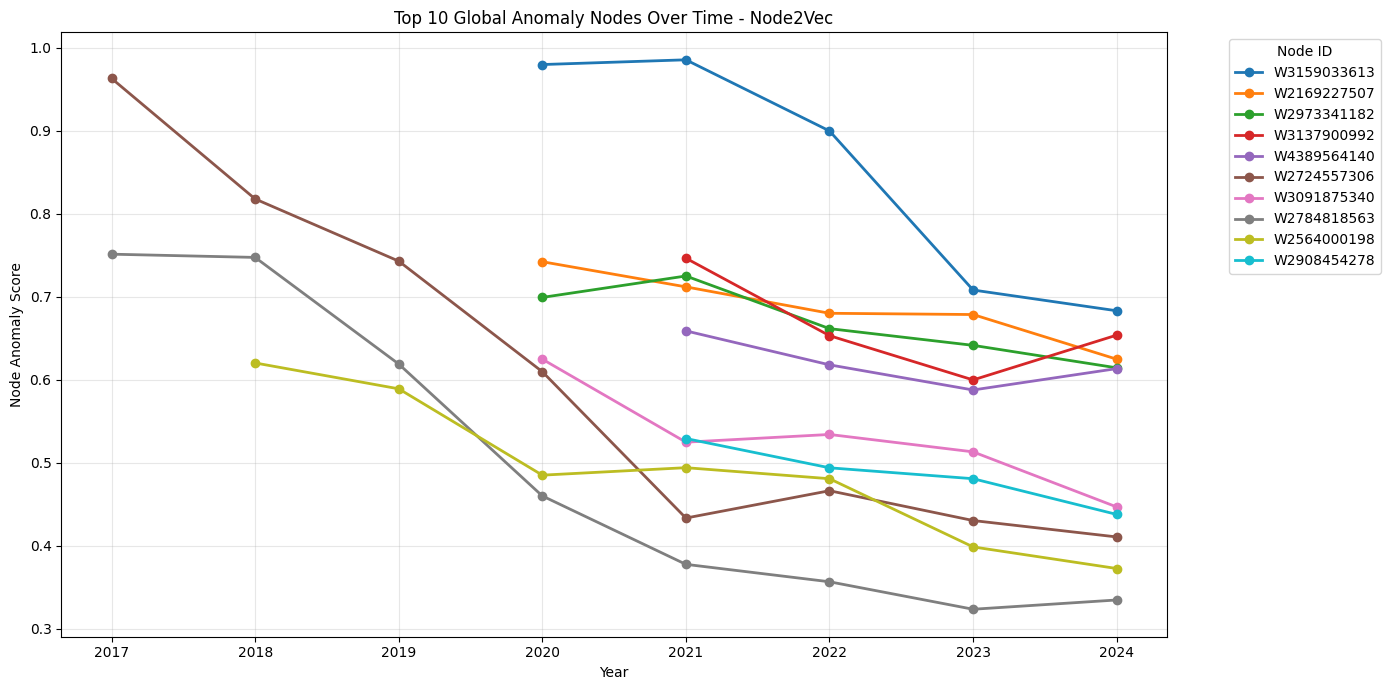

Saved: /content/gdrive/MyDrive/Final_project/visualization_results/node2vec_top10_global_anomaly_nodes_over_time.png


In [ ]:
# ----------------------------------------
# Top 10 global anomalous nodes over time according to Node2Vec
# ----------------------------------------
TOP_K = 10

# Minimum number of evaluated edges connected to a node.
MIN_INCIDENT_EDGES = 10

# Node must appear in at least this number of years.
MIN_YEARS_APPEARED = 4

# ----------------------------------------
# Load original edge stability scores
# ----------------------------------------
conn = sqlite3.connect(NODE2VEC_DB_FILE_DRIVE)

query = """
    SELECT year, source, target, edge_type, removal_count, reconstruction_count
    FROM edge_counts
    WHERE edge_type = 'original'
      AND removal_count > 0
"""

df_edges = pd.read_sql_query(query, conn)
conn.close()

# Compute stability score for each original edge.
df_edges["year"] = df_edges["year"].astype(int)
df_edges["edge_stability"] = df_edges["reconstruction_count"] / df_edges["removal_count"]

print("Original edges loaded:", len(df_edges))


# ----------------------------------------
# Convert edge stability to node stability
# ----------------------------------------

# Each edge affects both endpoint nodes: source and target.
source_nodes = df_edges[["year", "source", "edge_stability"]].rename(
    columns={"source": "node_id"}
)

target_nodes = df_edges[["year", "target", "edge_stability"]].rename(
    columns={"target": "node_id"}
)

# Combine both endpoints into one node-level table.
df_nodes = pd.concat([source_nodes, target_nodes], ignore_index=True)
df_nodes["node_id"] = df_nodes["node_id"].astype(str)


# ----------------------------------------
# Calculate node anomaly score per year
# ----------------------------------------
node_stability_per_year = (
    df_nodes
    .groupby(["year", "node_id"])
    .agg(
        node_stability=("edge_stability", "mean"),
        incident_edges=("edge_stability", "count")
    )
    .reset_index()
)

# Low stability means higher anomaly.
node_stability_per_year["node_anomaly_score"] = (
    1 - node_stability_per_year["node_stability"]
)

# Keep only nodes with enough evaluated edges.
node_stability_per_year = node_stability_per_year[
    node_stability_per_year["incident_edges"] >= MIN_INCIDENT_EDGES
]


# ----------------------------------------
# Select global Top 10 anomaly nodes
# ----------------------------------------
global_node_anomaly = (
    node_stability_per_year
    .groupby("node_id")
    .agg(
        avg_anomaly_score=("node_anomaly_score", "mean"),
        max_anomaly_score=("node_anomaly_score", "max"),
        years_appeared=("year", "nunique"),
        avg_incident_edges=("incident_edges", "mean")
    )
    .reset_index()
)

# Keep only nodes that appear across enough years.
global_node_anomaly = global_node_anomaly[
    global_node_anomaly["years_appeared"] >= MIN_YEARS_APPEARED
]

# Weighted anomaly also considers how many evaluated edges the node has.
global_node_anomaly["weighted_anomaly_score"] = (
    global_node_anomaly["avg_anomaly_score"] *
    np.log1p(global_node_anomaly["avg_incident_edges"])
)

# Select the top anomalous nodes by average anomaly score.
top10_global_anomaly_nodes = (
    global_node_anomaly
    .sort_values("avg_anomaly_score", ascending=False)
    .head(TOP_K)
    .reset_index(drop=True)
)

# Save top 10 anomalous nodes table.
output_csv = os.path.join(
    NODE2VEC_RESULTS_DIR,
    "node2vec_top10_global_anomaly_nodes.csv"
)

top10_global_anomaly_nodes.to_csv(output_csv, index=False)

print("Saved:", output_csv)
display(top10_global_anomaly_nodes)

# ----------------------------------------
# Plot anomaly score over years for global Top 10 nodes
# ----------------------------------------
top10_node_ids = top10_global_anomaly_nodes["node_id"].astype(str).tolist()

plot_df = node_stability_per_year[
    node_stability_per_year["node_id"].astype(str).isin(top10_node_ids)
].copy()

plt.figure(figsize=(14, 7))

# Plot anomaly trend for each selected node.
for node_id in top10_node_ids:
    node_df = plot_df[plot_df["node_id"].astype(str) == node_id].sort_values("year")

    plt.plot(
        node_df["year"],
        node_df["node_anomaly_score"],
        marker="o",
        linewidth=2,
        label=str(node_id)
    )

plt.xlabel("Year")
plt.ylabel("Node Anomaly Score")
plt.title("Top 10 Global Anomaly Nodes Over Time - Node2Vec")
plt.legend(title="Node ID", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.grid(True, alpha=0.3)

plt.tight_layout()

# Save anomaly trend plot.
output_path = os.path.join(
    VISUALIZATION_DIR,
    "node2vec_top10_global_anomaly_nodes_over_time.png"
)

plt.savefig(output_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", output_path)

## GraphSAGE Anomalous Nodes

Computes and visualizes the top anomalous nodes over time according to GraphSAGE, and saves the corresponding analysis outputs and graphs.


Processing GraphSAGE year 2015
Processing GraphSAGE year 2016
Processing GraphSAGE year 2017
Processing GraphSAGE year 2018
Processing GraphSAGE year 2019
Processing GraphSAGE year 2020
Processing GraphSAGE year 2021
Processing GraphSAGE year 2022
Processing GraphSAGE year 2023
Processing GraphSAGE year 2024
Original GraphSAGE edges loaded: 11660080
Saved: /content/gdrive/MyDrive/Final_project/graphsage_results/graphsage_top10_global_anomaly_nodes.csv


,node_id,avg_anomaly_score,max_anomaly_score,years_appeared,avg_incident_edges,total_incident_edges,weighted_anomaly_score
0,W56293434,0.743425,0.848946,7,267.142857,1870,4.156878
1,W2087928947,0.819107,0.925115,9,139.555556,1256,4.050980
2,W2546997942,0.963158,0.972973,6,36.500000,219,3.490812
3,W2519132385,0.755690,0.856535,7,98.000000,686,3.472484
4,W2225156818,0.590437,0.662934,7,261.285714,1829,3.288399
5,W2295598076,0.452126,0.589474,8,1169.875000,9359,3.194496
6,W1951724000,0.562167,0.782910,9,220.555556,1985,3.036080
7,W1552847225,0.469256,0.814588,10,589.600000,5896,2.994387
8,W3003257820,0.486949,0.548271,5,421.600000,2108,2.944300
9,W1985824294,0.693917,0.845696,8,66.125000,529,2.919002


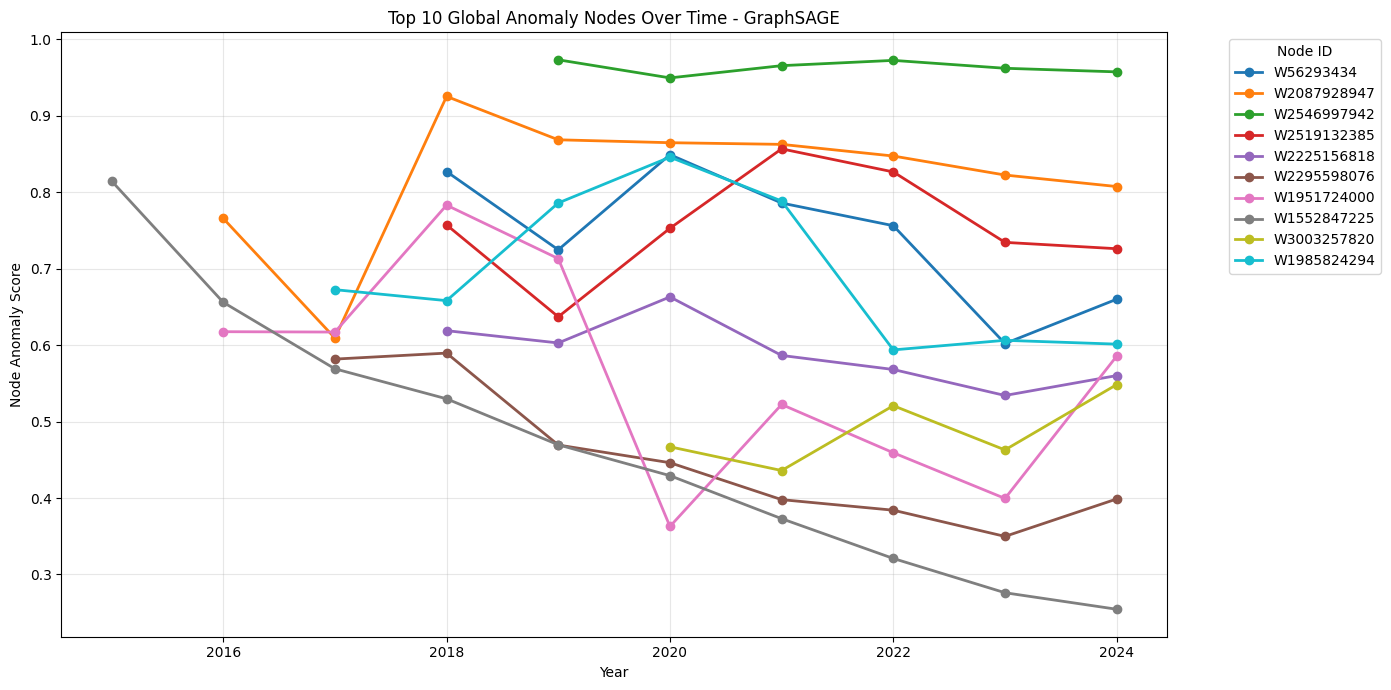

Saved: /content/gdrive/MyDrive/Final_project/visualization_results/graphsage_top10_global_anomaly_nodes_over_time.png


In [ ]:
# ----------------------------------------
# Top 10 global anomalous nodes over time according to GraphSAGE
# ----------------------------------------

START_YEAR = 2015
END_YEAR = 2024

TOP_K = 10
MIN_INCIDENT_EDGES = 10
MIN_YEARS_APPEARED = 4


def normalize_edge(edge):
    # Treat (u, v) and (v, u) as the same edge.
    u, v = edge
    return tuple(sorted((str(u), str(v))))


all_edge_rows = []

# ----------------------------------------
# Load GraphSAGE edge stability scores
# ----------------------------------------
for year in range(START_YEAR, END_YEAR + 1):

    checkpoint_file = os.path.join(
        GRAPHSAGE_CHECKPOINT_DIR,
        f"graphsage_stability_checkpoint_{year}.pkl"
    )

    nodes_snapshot_file = os.path.join(
        SNAPSHOTS_DIR,
        f"nodes_snapshot_{year}.csv"
    )

    edges_snapshot_file = os.path.join(
        SNAPSHOTS_DIR,
        f"edges_snapshot_{year}.csv"
    )

    # Skip year if required files are missing.
    if not os.path.exists(checkpoint_file):
        print(f"Missing checkpoint for year {year}")
        continue

    if not os.path.exists(nodes_snapshot_file) or not os.path.exists(edges_snapshot_file):
        print(f"Missing snapshot files for year {year}")
        continue

    print(f"Processing GraphSAGE year {year}")

    # Load saved removal/reconstruction counts.
    with open(checkpoint_file, "rb") as f:
        checkpoint = pickle.load(f)

    removal_counts_sage = checkpoint.get("removal_counts_sage", {})
    reconstruction_counts_sage = checkpoint.get("reconstruction_counts_sage", {})

    # Load original snapshot edges.
    nodes_df_year = pd.read_csv(nodes_snapshot_file)
    edges_df_year = pd.read_csv(edges_snapshot_file)

    valid_nodes = set(nodes_df_year["id"].astype(str))

    # Rebuild original edge set for this year.
    original_set = set()


    for row in edges_df_year.itertuples(index=False):
        source = str(row.source)
        target = str(row.target)

        if source in valid_nodes and target in valid_nodes:
            original_set.add(normalize_edge((source, target)))

    # Calculate stability only for original edges.
    for edge, removal_count in removal_counts_sage.items():

        if removal_count <= 0:
            continue

        norm_edge = normalize_edge(edge)

        if norm_edge not in original_set:
            continue

        reconstruction_count = reconstruction_counts_sage.get(edge, 0)
        edge_stability = reconstruction_count / removal_count

        source, target = norm_edge

        all_edge_rows.append({
            "year": year,
            "source": source,
            "target": target,
            "edge_stability": edge_stability
        })


df_edges = pd.DataFrame(all_edge_rows)

print("Original GraphSAGE edges loaded:", len(df_edges))

if df_edges.empty:
    raise ValueError("No original GraphSAGE edge scores were found. Check checkpoint files and snapshot files.")


# ----------------------------------------
# Convert edge stability to node stability
# ----------------------------------------

# Each edge contributes its stability score to both endpoint nodes.
source_nodes = df_edges[["year", "source", "edge_stability"]].rename(
    columns={"source": "node_id"}
)

target_nodes = df_edges[["year", "target", "edge_stability"]].rename(
    columns={"target": "node_id"}
)

df_nodes = pd.concat([source_nodes, target_nodes], ignore_index=True)
df_nodes["node_id"] = df_nodes["node_id"].astype(str)


# ----------------------------------------
# Calculate node anomaly score per year
# ----------------------------------------
# Node stability = average stability of all evaluated edges connected to that node.
node_stability_per_year = (
    df_nodes
    .groupby(["year", "node_id"])
    .agg(
        node_stability=("edge_stability", "mean"),
        incident_edges=("edge_stability", "count")
    )
    .reset_index()
)

# Lower stability means higher anomaly.
node_stability_per_year["node_anomaly_score"] = (
    1 - node_stability_per_year["node_stability"]
)

# Keep only nodes with enough evaluated connected edges.
node_stability_per_year = node_stability_per_year[
    node_stability_per_year["incident_edges"] >= MIN_INCIDENT_EDGES
]


# ----------------------------------------
# Select global Top 10 anomaly nodes
# ----------------------------------------

# Aggregate node anomaly behavior across years.
global_node_anomaly = (
    node_stability_per_year
    .groupby("node_id")
    .agg(
        avg_anomaly_score=("node_anomaly_score", "mean"),
        max_anomaly_score=("node_anomaly_score", "max"),
        years_appeared=("year", "nunique"),
        avg_incident_edges=("incident_edges", "mean"),
        total_incident_edges=("incident_edges", "sum")
    )
    .reset_index()
)

# Keep only nodes that appear in enough years.
global_node_anomaly = global_node_anomaly[
    global_node_anomaly["years_appeared"] >= MIN_YEARS_APPEARED
]

# Weighted score combines anomaly strength with amount of evidence.
global_node_anomaly["weighted_anomaly_score"] = (
    global_node_anomaly["avg_anomaly_score"] *
    np.log1p(global_node_anomaly["avg_incident_edges"])
)

# Select top 10 most anomalous nodes.
top10_global_anomaly_nodes = (
    global_node_anomaly
    .sort_values("weighted_anomaly_score", ascending=False)
    .head(TOP_K)
    .reset_index(drop=True)
)

# Save top 10 table.
output_csv = os.path.join(
    GRAPHSAGE_RESULTS_DIR,
    "graphsage_top10_global_anomaly_nodes.csv"
)

top10_global_anomaly_nodes.to_csv(output_csv, index=False)

print("Saved:", output_csv)
display(top10_global_anomaly_nodes)


# ----------------------------------------
# Plot anomaly score over years for global Top 10 nodes
# ----------------------------------------
top10_node_ids = top10_global_anomaly_nodes["node_id"].astype(str).tolist()

plot_df = node_stability_per_year[
    node_stability_per_year["node_id"].astype(str).isin(top10_node_ids)
].copy()

plt.figure(figsize=(14, 7))

# Plot anomaly trend for each selected node.
for node_id in top10_node_ids:
    node_df = plot_df[
        plot_df["node_id"].astype(str) == node_id
    ].sort_values("year")

    plt.plot(
        node_df["year"],
        node_df["node_anomaly_score"],
        marker="o",
        linewidth=2,
        label=str(node_id)
    )

plt.xlabel("Year")
plt.ylabel("Node Anomaly Score")
plt.title("Top 10 Global Anomaly Nodes Over Time - GraphSAGE")
plt.legend(title="Node ID", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.grid(True, alpha=0.3)

plt.tight_layout()

# Save plot.
output_path = os.path.join(
    VISUALIZATION_DIR,
    "graphsage_top10_global_anomaly_nodes_over_time.png"
)

plt.savefig(output_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", output_path)